# Mozart / Rossini Cadenza Analysis Notebook — hybrid deep run detection

这个版本将“跑花识别”从旧的 frame-wise 音高复杂度启发式，改成**混合深度转录 + 音符链检测**：

1. 仍用 **Demucs** 做人声 / 伴奏分离；
2. 优先用 **Basic Pitch** 的 note events 与 onset activation 做高召回候选音符边界；
3. 再用 **torchcrepe** 的高时间分辨率 F0 / periodicity 细化音符边界与音高；
4. 最后在音符序列上直接寻找“短、快、连续”的**跑花链**，其长度定义为链首音 onset 到链末音 offset 的时间跨度。

这比单纯依赖 `pYIN + 局部复杂度阈值` 更贴近你的数据设定：
- 莫扎特片段通常几乎整段都是连续跑花；
- 罗西尼片段通常是唱词中嵌入的局部跑花。

Notebook 直接顺序运行即可。

In [1]:

# -*- coding: utf-8 -*-
"""
Cadenza analysis notebook script.
"""
import sys
import subprocess
import importlib.util

REQUIRED = {
    "demucs": "demucs",
    "librosa": "librosa",
    "soundfile": "soundfile",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
    "scipy": "scipy",
    "tqdm": "tqdm",
    "torch": "torch",
}
missing = [pkg for pkg, mod in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

OPTIONAL_REQUIRE = [
    ("torchcrepe", "torchcrepe"),
]
# Basic Pitch 官方 README 列出的兼容 Python 版本到 3.11；若当前解释器更高，跳过自动安装，后续直接回退。
if sys.version_info < (3, 12):
    OPTIONAL_REQUIRE.append(("basic-pitch", "basic_pitch"))

for pkg, mod in OPTIONAL_REQUIRE:
    if importlib.util.find_spec(mod) is None:
        try:
            print(f"Trying optional package install: {pkg}")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        except Exception as exc:
            print(f"Optional package unavailable: {pkg} -> {exc}")

from pathlib import Path
import os
import shutil
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.ndimage import median_filter, uniform_filter1d
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.signal import find_peaks
import torch

try:
    import torchcrepe
    TORCHCREPE_AVAILABLE = True
    TORCHCREPE_ERROR = None
except Exception as exc:
    torchcrepe = None
    TORCHCREPE_AVAILABLE = False
    TORCHCREPE_ERROR = repr(exc)

try:
    from basic_pitch.inference import predict as basic_pitch_predict, Model as BasicPitchModel
    from basic_pitch import ICASSP_2022_MODEL_PATH
    from basic_pitch.constants import ANNOTATIONS_FPS
    BASIC_PITCH_AVAILABLE = True
    BASIC_PITCH_ERROR = None
except Exception as exc:
    basic_pitch_predict = None
    BasicPitchModel = None
    ICASSP_2022_MODEL_PATH = None
    ANNOTATIONS_FPS = None
    BASIC_PITCH_AVAILABLE = False
    BASIC_PITCH_ERROR = repr(exc)

BASIC_PITCH_MODEL = None

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams["figure.dpi"] = 140

DATA_DIR = Path("Dataset/Cadenza")
WORK_DIR = Path("Cadenza_Analysis_Results")
INPUT_WAV_DIR = WORK_DIR / "inputs_wav"
SEP_ROOT = WORK_DIR / "demucs_out"
VOCAL_DIR = WORK_DIR / "vocals"
ACC_DIR = WORK_DIR / "accompaniment"
FIG_DIR = WORK_DIR / "figures"
CSV_DIR = WORK_DIR / "csv"

for d in [WORK_DIR, INPUT_WAV_DIR, SEP_ROOT, VOCAL_DIR, ACC_DIR, FIG_DIR, CSV_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SR_ANALYSIS = 22050
SR_DEMUCS = 44100
HOP_LENGTH = 128
FRAME_LENGTH = 1024
FMIN = librosa.note_to_hz("G2")
FMAX = librosa.note_to_hz("C6")
CREPE_SR = 16000
CREPE_HOP = 80                      # 5 ms
FALLBACK_HOP = 64
FALLBACK_FRAME = 1024
BP_ONSET_THRESHOLD = 0.32
BP_FRAME_THRESHOLD = 0.15
BP_MIN_NOTE_MS = 35.0
NOTE_MIN_DUR_S = 0.035
NOTE_MAX_MERGE_GAP_S = 0.025
NOTE_SAME_PITCH_TOL_ST = 0.35
RUN_WINDOW_S = 0.80
RUN_MAX_NOTE_DUR_S = 0.22
RUN_MAX_IOI_S = 0.18
RUN_MAX_GAP_S = 0.08
RUN_MIN_NOTES = 4
RUN_MIN_RATE_HZ = 4.8
RUN_MIN_SHORT_RATIO = 0.55
RUN_MIN_VOICED_COV = 0.72
GLOBAL_RUN_RATIO = 0.55
GLOBAL_RUN_MEDIAN_RATE = 5.0
GLOBAL_RUN_MERGE_GAP_S = 0.15
SUPPORTED_SUFFIXES = {".m4a", ".wav", ".mp3", ".flac", ".aac"}



Trying optional package install: torchcrepe


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Trying optional package install: basic-pitch


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
/Users/xz/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
scikit-learn version 1.6.1 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
Torch version 2.8.0 has not been tested with coremltools. You may run into unexpected errors. Torch 2.7.0 is the most recent version that has been tested.


In [2]:
def list_audio_files(data_dir: Path) -> pd.DataFrame:
    files = sorted([p for p in data_dir.iterdir() if p.is_file() and p.suffix.lower() in SUPPORTED_SUFFIXES])
    if not files:
        raise FileNotFoundError(f"在 {data_dir} 中没有找到音频文件。")
    rows = []
    for p in files:
        stem = p.stem
        low = stem.lower()
        if low.startswith("mozart"):
            composer = "Mozart"
        elif low.startswith("rossini"):
            composer = "Rossini"
        else:
            composer = "Unknown"
        rows.append({"path": p, "stem": stem, "composer": composer})
    df = pd.DataFrame(rows)
    return df

def convert_inputs_to_wav(df: pd.DataFrame, out_dir: Path, target_sr: int = 44100):
    wav_paths = []
    for p in tqdm(df["path"], desc="Converting input audio to wav"):
        out_path = out_dir / f"{Path(p).stem}.wav"
        if not out_path.exists():
            y, _ = librosa.load(p, sr=target_sr, mono=False)
            if y.ndim == 1:
                y = np.vstack([y, y])
            sf.write(out_path, y.T, target_sr)
        wav_paths.append(out_path)
    return wav_paths

def run_demucs_two_stems(wav_paths, sep_root: Path, vocal_dir: Path, acc_dir: Path, model_name: str = "htdemucs"):
    expected = [vocal_dir / f"{Path(p).stem}_vocals.wav" for p in wav_paths]
    if expected and all(p.exists() for p in expected):
        print("Demucs 分离结果已存在，直接复用缓存。")
        return

    device = "cuda" if torch.cuda.is_available() else "cpu"
    cmd = [
        sys.executable,
        "-m",
        "demucs",
        "-n",
        model_name,
        "--two-stems=vocals",
        "-d",
        device,
        "-o",
        str(sep_root),
    ] + [str(p) for p in wav_paths]

    print("Running Demucs on device:", device)
    subprocess.check_call(cmd)

    model_root = sep_root / model_name
    for wp in wav_paths:
        stem_dir = model_root / Path(wp).stem
        vocal_src = stem_dir / "vocals.wav"
        acc_src = stem_dir / "no_vocals.wav"
        if not vocal_src.exists():
            raise FileNotFoundError(f"缺少 Demucs 输出: {vocal_src}")
        shutil.copy2(vocal_src, vocal_dir / f"{Path(wp).stem}_vocals.wav")
        shutil.copy2(acc_src, acc_dir / f"{Path(wp).stem}_acc.wav")

def load_mono_normalised(path: Path, sr: int = SR_ANALYSIS):
    y, _ = librosa.load(path, sr=sr, mono=True)
    if len(y) == 0:
        return y, sr
    y, _ = librosa.effects.trim(y, top_db=35)
    peak = np.max(np.abs(y)) if len(y) else 0.0
    if peak > 0:
        y = y / peak
    return y, sr


def get_basic_pitch_model():
    global BASIC_PITCH_MODEL
    if not BASIC_PITCH_AVAILABLE:
        return None
    if BASIC_PITCH_MODEL is None:
        BASIC_PITCH_MODEL = BasicPitchModel(ICASSP_2022_MODEL_PATH)
    return BASIC_PITCH_MODEL


def fill_short_nan_gaps(x, max_gap: int = 4):
    x = np.asarray(x, dtype=float).copy()
    n = len(x)
    i = 0
    while i < n:
        if np.isnan(x[i]):
            j = i
            while j < n and np.isnan(x[j]):
                j += 1
            gap = j - i
            if i > 0 and j < n and gap <= max_gap:
                x[i:j] = np.linspace(x[i - 1], x[j], gap + 2)[1:-1]
            i = j
        else:
            i += 1
    return x


def robust_z(x):
    x = np.asarray(x, dtype=float)
    if not np.any(np.isfinite(x)):
        return np.full_like(x, np.nan, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    scale = 1.4826 * mad + 1e-8
    return (x - med) / scale


def moving_average(x, win: int):
    win = max(1, int(win))
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(np.nan_to_num(x, nan=0.0), kernel, mode="same")


def mask_to_segments(mask):
    mask = np.asarray(mask, dtype=bool)
    if len(mask) == 0:
        return []
    diff = np.diff(mask.astype(int))
    starts = list(np.where(diff == 1)[0] + 1)
    ends = list(np.where(diff == -1)[0] + 1)
    if mask[0]:
        starts = [0] + starts
    if mask[-1]:
        ends = ends + [len(mask)]
    return list(zip(starts, ends))


def merge_segments(segments, max_gap: int):
    if not segments:
        return []
    merged = [list(segments[0])]
    for s, e in segments[1:]:
        if s - merged[-1][1] <= max_gap:
            merged[-1][1] = e
        else:
            merged.append([s, e])
    return [tuple(m) for m in merged]


def segments_to_mask(segments, n: int):
    mask = np.zeros(n, dtype=bool)
    for s, e in segments:
        mask[s:e] = True
    return mask


def normalise_unit(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    finite = np.isfinite(x)
    if not finite.any():
        return out
    lo, hi = np.nanpercentile(x[finite], [5, 95])
    if hi <= lo + 1e-8:
        out[finite] = 0.0
        return out
    out[finite] = np.clip((x[finite] - lo) / (hi - lo), 0.0, 1.0)
    return out


def nearest_index(sorted_times: np.ndarray, t: float) -> int:
    idx = int(np.searchsorted(sorted_times, t, side="left"))
    if idx <= 0:
        return 0
    if idx >= len(sorted_times):
        return len(sorted_times) - 1
    if abs(sorted_times[idx] - t) < abs(sorted_times[idx - 1] - t):
        return idx
    return idx - 1


def cluster_time_points(time_points, tol: float = 0.025):
    vals = sorted([float(t) for t in time_points if np.isfinite(t)])
    if not vals:
        return []
    groups = [[vals[0]]]
    for t in vals[1:]:
        if t - groups[-1][-1] <= tol:
            groups[-1].append(t)
        else:
            groups.append([t])
    return [float(np.mean(g)) for g in groups]


def interp_feature_to_times(src_values, src_times, dst_times):
    src_values = np.asarray(src_values, dtype=float)
    src_times = np.asarray(src_times, dtype=float)
    dst_times = np.asarray(dst_times, dtype=float)
    if len(src_values) == 0 or len(src_times) == 0:
        return np.zeros_like(dst_times, dtype=float)
    finite = np.isfinite(src_values) & np.isfinite(src_times)
    if not finite.any():
        return np.zeros_like(dst_times, dtype=float)
    return np.interp(dst_times, src_times[finite], src_values[finite], left=src_values[finite][0], right=src_values[finite][-1])


def smooth_pitch_for_boundaries(midi, dt: float, gap_s: float = 0.03, median_s: float = 0.015, mean_s: float = 0.025):
    x = np.asarray(midi, dtype=float).copy()
    if not np.any(np.isfinite(x)):
        return np.full_like(x, np.nan, dtype=float)

    x = fill_short_nan_gaps(x, max_gap=max(1, int(round(gap_s / dt))))
    valid = np.isfinite(x)
    idx = np.where(valid)[0]
    if len(idx) == 0:
        return np.full_like(x, np.nan, dtype=float)

    interp = np.interp(np.arange(len(x)), idx, x[idx])
    med_n = max(3, int(round(median_s / dt)))
    if med_n % 2 == 0:
        med_n += 1
    mean_n = max(3, int(round(mean_s / dt)))
    out = median_filter(interp, size=med_n, mode="nearest")
    out = uniform_filter1d(out, size=mean_n, mode="nearest")
    out[~valid] = np.nan
    return out


def extract_pitch_track(y, sr):
    """
    Primary backend: torchcrepe (neural pitch tracker).
    Fallback backend: librosa.pyin.

    Returns
    -------
    times, midi, confidence, rms, onset_env, backend
    """
    if TORCHCREPE_AVAILABLE:
        try:
            y_proc = librosa.resample(y, orig_sr=sr, target_sr=CREPE_SR) if sr != CREPE_SR else y
            audio = torch.tensor(y_proc, dtype=torch.float32).unsqueeze(0)
            device = "cuda:0" if torch.cuda.is_available() else "cpu"
            audio = audio.to(device)
            batch_size = 2048 if device.startswith("cuda") else 1024

            with torch.no_grad():
                pitch, periodicity = torchcrepe.predict(
                    audio,
                    CREPE_SR,
                    CREPE_HOP,
                    FMIN,
                    FMAX,
                    model="full",
                    decoder=torchcrepe.decode.viterbi,
                    return_periodicity=True,
                    batch_size=batch_size,
                    device=device,
                    pad=True,
                )
                periodicity = torchcrepe.threshold.Silence(-60.0)(periodicity, audio, CREPE_SR, CREPE_HOP)
                periodicity = torchcrepe.filter.median(periodicity, 3)
                pitch = torchcrepe.threshold.At(0.14)(pitch, periodicity)
                pitch = torchcrepe.filter.mean(pitch, 3)

            pitch = pitch.squeeze(0).detach().cpu().numpy().astype(float)
            periodicity = periodicity.squeeze(0).detach().cpu().numpy().astype(float)
            times = np.arange(len(pitch), dtype=float) * (CREPE_HOP / CREPE_SR)
            midi = librosa.hz_to_midi(pitch)
            midi[~np.isfinite(midi)] = np.nan
            rms = librosa.feature.rms(y=y_proc, frame_length=1024, hop_length=CREPE_HOP, center=True)[0]
            onset_env = librosa.onset.onset_strength(y=y_proc, sr=CREPE_SR, hop_length=CREPE_HOP)
            return times, midi, periodicity, rms, onset_env, "torchcrepe"
        except Exception as exc:
            print(f"torchcrepe backend failed -> fallback to pYIN: {exc}")

    # Fallback to pYIN
    hop_length = FALLBACK_HOP
    frame_length = FALLBACK_FRAME
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length, center=True)[0]
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
    times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)
    try:
        f0, voiced_flag, voiced_prob = librosa.pyin(
            y,
            fmin=FMIN,
            fmax=FMAX,
            sr=sr,
            frame_length=frame_length,
            hop_length=hop_length,
        )
        f0 = np.asarray(f0, dtype=float)
        voiced_prob = np.asarray(np.where(np.isnan(f0), 0.0, voiced_prob), dtype=float)
        voiced_flag = np.asarray(np.where(np.isnan(f0), False, voiced_flag), dtype=bool)
        energy_thr = np.percentile(rms, 10)
        mask = voiced_flag & (voiced_prob >= 0.18) & (rms >= energy_thr)
        if mask.sum() < max(8, int(0.03 * len(mask))):
            mask = voiced_flag & (voiced_prob >= 0.10)
        f0[~mask] = np.nan
    except Exception:
        f0 = librosa.yin(
            y,
            fmin=FMIN,
            fmax=FMAX,
            sr=sr,
            frame_length=frame_length,
            hop_length=hop_length,
        ).astype(float)
        voiced_prob = np.where(np.isnan(f0), 0.0, 0.5)
        f0[rms < np.percentile(rms, 15)] = np.nan

    midi = librosa.hz_to_midi(f0)
    midi[np.isinf(midi)] = np.nan
    return times, midi, voiced_prob, rms, onset_env, "pyin"


def extract_basic_pitch_outputs(vocal_path: Path):
    if not BASIC_PITCH_AVAILABLE:
        return [], None, None
    try:
        model = get_basic_pitch_model()
        model_output, _, note_events = basic_pitch_predict(
            str(vocal_path),
            model,
            onset_threshold=BP_ONSET_THRESHOLD,
            frame_threshold=BP_FRAME_THRESHOLD,
            minimum_note_length=BP_MIN_NOTE_MS,
            minimum_frequency=float(FMIN),
            maximum_frequency=float(FMAX),
            melodia_trick=True,
        )
        notes = []
        for st, en, pitch_midi, amp, bends in note_events:
            notes.append({
                "start": float(st),
                "end": float(en),
                "pitch_midi": float(pitch_midi),
                "amplitude": float(amp),
                "source": "basic_pitch",
            })
        return notes, model_output, "basic_pitch"
    except Exception as exc:
        print(f"basic-pitch backend unavailable for {vocal_path.name}: {exc}")
        return [], None, None


def onset_candidates_from_basic_pitch(model_output):
    if model_output is None or ANNOTATIONS_FPS is None:
        return [], None, None
    try:
        onset_sal = np.asarray(model_output["onset"], dtype=float)
        if onset_sal.ndim == 2:
            onset_sal = onset_sal.max(axis=1)
        bp_times = np.arange(len(onset_sal), dtype=float) / float(ANNOTATIONS_FPS)
        onset_sal = normalise_unit(onset_sal)
        height = max(0.18, float(np.nanpercentile(onset_sal[np.isfinite(onset_sal)], 70))) if np.isfinite(onset_sal).any() else 0.18
        peaks, _ = find_peaks(onset_sal, height=height, distance=max(1, int(round(0.03 * ANNOTATIONS_FPS))))
        return list(bp_times[peaks]), onset_sal, bp_times
    except Exception:
        return [], None, None


def boundary_candidates_from_pitch(times, midi, onset_env):
    times = np.asarray(times, dtype=float)
    midi = np.asarray(midi, dtype=float)
    onset_env = np.asarray(onset_env, dtype=float)
    if len(times) == 0:
        return []
    dt = float(np.median(np.diff(times))) if len(times) >= 2 else 0.01
    smooth = smooth_pitch_for_boundaries(midi, dt=dt)
    jump = np.abs(np.diff(smooth, prepend=smooth[0] if np.isfinite(smooth[0]) else np.nan))
    jump[~np.isfinite(jump)] = 0.0
    jump = moving_average(jump, max(1, int(round(0.02 / max(dt, 1e-8)))))
    flux = normalise_unit(onset_env)
    score = np.nan_to_num(robust_z(jump), nan=0.0) + 0.60 * np.nan_to_num(robust_z(flux), nan=0.0)
    peak_distance = max(1, int(round(0.03 / max(dt, 1e-8))))
    peaks, _ = find_peaks(score, distance=peak_distance, prominence=0.15)

    finite_score = np.isfinite(score)
    thr_score = float(np.nanpercentile(score[finite_score], 65)) if finite_score.any() else 0.0
    valid_jump = np.isfinite(jump)
    thr_jump = max(0.45, float(np.nanpercentile(jump[valid_jump], 60))) if valid_jump.any() else 0.45
    valid_flux = np.isfinite(flux)
    thr_flux = max(0.15, float(np.nanpercentile(flux[valid_flux], 70))) if valid_flux.any() else 0.15

    cand = []
    for p in peaks:
        if score[p] >= thr_score and (jump[p] >= thr_jump or flux[p] >= thr_flux):
            cand.append(float(times[p]))

    voiced = np.isfinite(midi)
    for s, e in mask_to_segments(voiced):
        cand.append(float(times[s]))
        cand.append(float(times[e - 1] + dt))

    return cand


def build_boundaries(times, midi, onset_env, basic_pitch_events=None, basic_pitch_model_output=None):
    dt = float(np.median(np.diff(times))) if len(times) >= 2 else 0.01
    end_t = float(times[-1] + dt) if len(times) else 0.0
    cand = [0.0, end_t]
    cand += boundary_candidates_from_pitch(times, midi, onset_env)

    if basic_pitch_events:
        for ev in basic_pitch_events:
            cand.extend([float(ev["start"]), float(ev["end"])])

    bp_onset_cand, _, _ = onset_candidates_from_basic_pitch(basic_pitch_model_output)
    cand += bp_onset_cand

    # Keep inside range only
    cand = [min(max(0.0, float(t)), end_t) for t in cand]
    cand = cluster_time_points(cand, tol=0.025)
    cand = sorted(set([round(t, 4) for t in cand]))

    # Remove too-tight boundaries
    cleaned = [cand[0]] if cand else []
    for t in cand[1:]:
        if t - cleaned[-1] >= 0.015:
            cleaned.append(t)
    if cleaned and cleaned[-1] < end_t:
        cleaned.append(end_t)
    return cleaned


def merge_note_events(notes, max_gap_s: float = NOTE_MAX_MERGE_GAP_S, pitch_tol_st: float = NOTE_SAME_PITCH_TOL_ST):
    if not notes:
        return []
    notes = sorted(notes, key=lambda d: (d["start"], d["end"]))
    merged = [dict(notes[0])]
    for note in notes[1:]:
        prev = merged[-1]
        gap = note["start"] - prev["end"]
        pitch_close = abs(note["pitch_midi"] - prev["pitch_midi"]) <= pitch_tol_st
        if gap <= max_gap_s and pitch_close:
            prev["end"] = max(prev["end"], note["end"])
            prev["amplitude"] = float(np.nanmean([prev.get("amplitude", np.nan), note.get("amplitude", np.nan)]))
            prev["source"] = prev.get("source", "fused")
        else:
            merged.append(dict(note))
    return merged


def refine_note_events(times, midi, confidence, onset_env, basic_pitch_events=None, basic_pitch_model_output=None):
    """
    Hybrid note segmentation:
    1) Basic Pitch note events + raw onset activations provide high-recall candidate boundaries;
    2) torchcrepe/pYIN contour provides sub-note pitch continuity and voiced support;
    3) final notes are rebuilt on the fused boundary grid.
    """
    times = np.asarray(times, dtype=float)
    midi = np.asarray(midi, dtype=float)
    confidence = np.asarray(confidence, dtype=float)
    onset_env = np.asarray(onset_env, dtype=float)
    if len(times) == 0:
        return []

    dt = float(np.median(np.diff(times))) if len(times) >= 2 else 0.01
    boundaries = build_boundaries(times, midi, onset_env, basic_pitch_events=basic_pitch_events, basic_pitch_model_output=basic_pitch_model_output)

    notes = []
    for a, b in zip(boundaries[:-1], boundaries[1:]):
        if b - a < 0.015:
            continue
        idx = (times >= a) & (times < b)
        if not idx.any():
            continue
        seg_midi = midi[idx]
        seg_conf = confidence[idx]
        voiced = np.isfinite(seg_midi)
        voiced_cov = float(np.mean(voiced))
        if voiced_cov < 0.45:
            continue

        seg_times = times[idx]
        voiced_times = seg_times[voiced]
        seg_pitch = seg_midi[voiced]
        if len(seg_pitch) == 0:
            continue

        pitch_val = float(np.nanmedian(seg_pitch))
        start_t = float(voiced_times[0])
        end_t = float(voiced_times[-1] + dt)
        dur = end_t - start_t
        if dur < NOTE_MIN_DUR_S:
            continue

        amp = float(np.nanmedian(seg_conf[voiced])) if np.isfinite(seg_conf[voiced]).any() else np.nan
        notes.append({
            "start": start_t,
            "end": end_t,
            "pitch_midi": pitch_val,
            "duration": dur,
            "amplitude": amp,
            "source": "fused",
        })

    notes = merge_note_events(notes)

    # If Basic Pitch exists, preserve ultra-short notes that were explicitly predicted and not covered by fusion.
    if basic_pitch_events:
        covered = []
        for bp in basic_pitch_events:
            overlaps = False
            for n in notes:
                ov = max(0.0, min(bp["end"], n["end"]) - max(bp["start"], n["start"]))
                if ov >= 0.50 * min(bp["end"] - bp["start"], n["end"] - n["start"]):
                    overlaps = True
                    break
            if not overlaps and (bp["end"] - bp["start"]) >= NOTE_MIN_DUR_S:
                covered.append(dict(bp))
        notes = merge_note_events(sorted(notes + covered, key=lambda d: (d["start"], d["end"])))

    # Recompute durations
    for n in notes:
        n["duration"] = float(n["end"] - n["start"])
    return notes


def notes_to_frame_pitch(times, notes):
    x = np.full(len(times), np.nan, dtype=float)
    for n in notes:
        idx = (times >= n["start"]) & (times < n["end"])
        x[idx] = n["pitch_midi"]
    return x


def time_segments_to_frame_segments(segments_t, times):
    if len(times) == 0:
        return []
    dt = float(np.median(np.diff(times))) if len(times) >= 2 else 0.01
    out = []
    for st, en in segments_t:
        s = int(np.searchsorted(times, st, side="left"))
        e = int(np.searchsorted(times, max(st + 1e-6, en - dt * 0.5), side="right"))
        s = max(0, min(s, len(times) - 1))
        e = max(s + 1, min(e, len(times)))
        out.append((s, e))
    return out


def coverage_ratio_on_voiced(times, voiced_mask, start_t, end_t):
    idx = (times >= start_t) & (times < end_t)
    if not idx.any():
        return 0.0
    return float(np.mean(voiced_mask[idx]))


def merge_time_segments(segments_t, max_gap_s: float):
    if not segments_t:
        return []
    segs = sorted([(float(s), float(e)) for s, e in segments_t], key=lambda z: (z[0], z[1]))
    merged = [list(segs[0])]
    for s, e in segs[1:]:
        if s - merged[-1][1] <= max_gap_s:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [tuple(m) for m in merged]


def extend_segments_to_voiced(segments_t, voiced_segments_t, max_gap_s: float = 0.12):
    out = []
    for st, en in segments_t:
        new_st, new_en = st, en
        for vs, ve in voiced_segments_t:
            if ve < st - max_gap_s or vs > en + max_gap_s:
                continue
            if abs(st - vs) <= max_gap_s or (vs <= st <= ve):
                new_st = min(new_st, vs)
            if abs(ve - en) <= max_gap_s or (vs <= en <= ve):
                new_en = max(new_en, ve)
        out.append((new_st, new_en))
    return merge_time_segments(out, max_gap_s=max_gap_s)


def note_local_statistics(notes, window_s: float = RUN_WINDOW_S):
    n = len(notes)
    if n == 0:
        return np.array([]), np.array([])
    onsets = np.array([d["start"] for d in notes], dtype=float)
    durs = np.array([d["duration"] for d in notes], dtype=float)
    rates = np.zeros(n, dtype=float)
    short_ratio = np.zeros(n, dtype=float)
    half = window_s / 2
    for i, t in enumerate(onsets):
        m = (onsets >= t - half) & (onsets <= t + half)
        rates[i] = float(np.sum(m) / window_s)
        short_ratio[i] = float(np.mean(durs[m] <= RUN_MAX_NOTE_DUR_S)) if np.any(m) else 0.0
    return rates, short_ratio


def detect_run_segments_from_notes(notes, times, voiced_mask):
    """
    以音符链为核心，而不是以高音区或纯 frame-wise 复杂度为核心。

    记音符事件为 N = {(s_i, e_i, p_i)}_{i=1}^M，
    d_i = e_i - s_i,  ioi_i = s_{i+1} - s_i,  g_i = max(0, s_{i+1} - e_i).

    先构造“相邻音符是否属于同一跑花链”的连接关系
        connect(i, i+1) = 1( ioi_i <= τ_ioi and g_i <= τ_gap ).

    再对每条最大链 C = {i, ..., j} 计算
        rate(C)        = |C| / (e_j - s_i),
        short(C)       = mean_k 1(d_k <= d_max),
        voiced(C)      = voiced-coverage on [s_i, e_j].

    判定为跑花段当且仅当
        |C| >= N_min, rate(C) >= r_min, short(C) >= q_min, voiced(C) >= v_min.

    这样连续跑花长度直接定义为
        L(C) = e_j - s_i,
    也就是链首音 onset 到链末音 offset 的时间跨度。
    """
    if len(notes) == 0:
        empty = np.full(len(times), np.nan, dtype=float)
        return [], np.zeros(len(times), dtype=bool), {
            "density": empty.copy(),
            "speed": empty.copy(),
            "complexity": empty.copy(),
            "unique_states": empty.copy(),
            "score": empty.copy(),
            "chain_table": pd.DataFrame(),
        }

    notes = sorted(notes, key=lambda d: (d["start"], d["end"]))
    onsets = np.array([d["start"] for d in notes], dtype=float)
    offsets = np.array([d["end"] for d in notes], dtype=float)
    durs = np.array([d["duration"] for d in notes], dtype=float)
    pitches = np.array([d["pitch_midi"] for d in notes], dtype=float)

    local_rates, local_short_ratio = note_local_statistics(notes, window_s=RUN_WINDOW_S)

    chains = []
    a = 0
    for i in range(len(notes) - 1):
        ioi = onsets[i + 1] - onsets[i]
        gap = max(0.0, onsets[i + 1] - offsets[i])
        connect = (ioi <= RUN_MAX_IOI_S) and (gap <= RUN_MAX_GAP_S)
        if not connect:
            chains.append((a, i))
            a = i + 1
    chains.append((a, len(notes) - 1))

    chain_rows = []
    kept_segments_t = []
    for cid, (i, j) in enumerate(chains):
        st = onsets[i]
        en = offsets[j]
        dur = max(en - st, 1e-8)
        chain_n = j - i + 1
        chain_rate = float(chain_n / dur)
        chain_short = float(np.mean(durs[i:j + 1] <= RUN_MAX_NOTE_DUR_S))
        chain_med_dur = float(np.median(durs[i:j + 1]))
        chain_span = float(np.nanmax(pitches[i:j + 1]) - np.nanmin(pitches[i:j + 1])) if chain_n >= 1 else np.nan
        chain_travel = float(np.nansum(np.abs(np.diff(pitches[i:j + 1])))) if chain_n >= 2 else 0.0
        voiced_cov = coverage_ratio_on_voiced(times, voiced_mask, st, en)
        score = (
            1.20 * robust_z([chain_rate])[0]
            + 0.80 * robust_z([chain_short])[0]
            + 0.50 * robust_z([voiced_cov])[0]
        ) if np.isfinite(chain_rate) else np.nan
        keep = (
            chain_n >= RUN_MIN_NOTES
            and chain_rate >= RUN_MIN_RATE_HZ
            and chain_short >= RUN_MIN_SHORT_RATIO
            and voiced_cov >= RUN_MIN_VOICED_COV
        )
        chain_rows.append({
            "chain_id": cid,
            "note_start_idx": i,
            "note_end_idx": j,
            "start": st,
            "end": en,
            "duration": dur,
            "n_notes": chain_n,
            "note_rate_hz": chain_rate,
            "short_note_ratio": chain_short,
            "median_note_dur_s": chain_med_dur,
            "voiced_coverage": voiced_cov,
            "pitch_span_st": chain_span,
            "pitch_travel_st": chain_travel,
            "keep": bool(keep),
        })
        if keep:
            kept_segments_t.append((st, en))

    kept_segments_t = merge_time_segments(kept_segments_t, max_gap_s=0.08)

    voiced_segments_t = []
    dt = float(np.median(np.diff(times))) if len(times) >= 2 else 0.01
    for s, e in mask_to_segments(voiced_mask):
        voiced_segments_t.append((float(times[s]), float(times[e - 1] + dt)))

    kept_total = float(sum(e - s for s, e in kept_segments_t))
    voiced_total = float(sum(e - s for s, e in voiced_segments_t))
    kept_rates = [r["note_rate_hz"] for r in chain_rows if r["keep"]]
    median_rate = float(np.median(kept_rates)) if kept_rates else 0.0

    # 全片几乎都是跑花时，做一个 clip-level closing / extension。
    if voiced_total > 0 and kept_total / voiced_total >= GLOBAL_RUN_RATIO and median_rate >= GLOBAL_RUN_MEDIAN_RATE:
        kept_segments_t = merge_time_segments(kept_segments_t, max_gap_s=GLOBAL_RUN_MERGE_GAP_S)
        kept_segments_t = extend_segments_to_voiced(kept_segments_t, voiced_segments_t, max_gap_s=0.12)

        expanded_total = float(sum(e - s for s, e in kept_segments_t))
        if expanded_total / voiced_total >= 0.75:
            # 若扩展后已经覆盖了绝大多数有声区域，则将有声区整体视为连续跑花。
            kept_segments_t = [seg for seg in voiced_segments_t]

    run_segments_frames = time_segments_to_frame_segments(kept_segments_t, times)
    run_mask = segments_to_mask(run_segments_frames, len(times))
    run_mask &= voiced_mask

    # Frame-wise diagnostics for plotting / later summary
    density = np.full(len(times), np.nan, dtype=float)
    speed = np.full(len(times), np.nan, dtype=float)
    complexity = np.full(len(times), np.nan, dtype=float)
    unique_states = np.full(len(times), np.nan, dtype=float)

    for idx, t in enumerate(times):
        if not voiced_mask[idx]:
            continue
        left, right = t - RUN_WINDOW_S / 2, t + RUN_WINDOW_S / 2
        m = (onsets >= left) & (onsets <= right)
        if not np.any(m):
            density[idx] = 0.0
            speed[idx] = 0.0
            complexity[idx] = 0.0
            unique_states[idx] = 0.0
            continue
        loc_pitch = pitches[m]
        loc_dur = durs[m]
        density[idx] = float(np.sum(m) / RUN_WINDOW_S)
        speed[idx] = float(np.nansum(np.abs(np.diff(loc_pitch))) / RUN_WINDOW_S) if np.sum(m) >= 2 else 0.0
        complexity[idx] = float(np.mean(loc_dur <= RUN_MAX_NOTE_DUR_S))
        unique_states[idx] = float(len(np.unique(np.round(loc_pitch * 2) / 2)))

    score = (
        1.00 * np.nan_to_num(robust_z(density), nan=0.0)
        + 0.70 * np.nan_to_num(robust_z(complexity), nan=0.0)
        + 0.40 * np.nan_to_num(robust_z(speed), nan=0.0)
        + 0.25 * np.nan_to_num(robust_z(unique_states), nan=0.0)
    )
    score[~voiced_mask] = np.nan

    return kept_segments_t, run_mask, {
        "density": density,
        "speed": speed,
        "complexity": complexity,
        "unique_states": unique_states,
        "score": score,
        "chain_table": pd.DataFrame(chain_rows),
    }


def collapse_note_sequence(notes, quant: float = 0.5):
    if not notes:
        return np.array([], dtype=float)
    seq = np.array([n["pitch_midi"] for n in notes], dtype=float)
    if len(seq) == 0:
        return np.array([], dtype=float)
    q = np.round(seq / quant) * quant
    out = [q[0]]
    for v in q[1:]:
        if v != out[-1]:
            out.append(v)
    return np.asarray(out, dtype=float)


def ratio_geq(x, thr: float):
    x = np.asarray(x, dtype=float)
    x = np.abs(x[np.isfinite(x)])
    if len(x) == 0:
        return np.nan
    return float(np.mean(x >= thr))


def direction_change_rate(intervals, eps: float = 0.5):
    d = np.asarray(intervals, dtype=float)
    d = d[np.isfinite(d)]
    if len(d) < 2:
        return np.nan
    s = np.sign(np.where(np.abs(d) < eps, 0.0, d))
    s = s[s != 0]
    if len(s) < 2:
        return np.nan
    return float(np.mean(s[1:] != s[:-1]))


def recurrence_rate(seq, tol: float = 1.0, max_points: int = 300):
    x = np.asarray(seq, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 3:
        return np.nan
    if n > max_points:
        idx = np.linspace(0, n - 1, max_points).astype(int)
        x = x[idx]
        n = len(x)
    D = np.abs(x[:, None] - x[None, :])
    rr = (np.sum(D <= tol) - n) / (n * (n - 1))
    return float(rr)


def shannon_entropy(seq, quant: float = 1.0):
    x = np.asarray(seq, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return np.nan
    q = np.round(x / quant) * quant
    _, counts = np.unique(q, return_counts=True)
    p = counts / counts.sum()
    return float(-(p * np.log(p + 1e-12)).sum())


def ngram_repeat_ratio(seq, n: int = 3, quant: float = 1.0):
    x = np.asarray(seq, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < n:
        return np.nan
    q = tuple(np.round(x / quant).astype(int))
    grams = [q[i:i + n] for i in range(len(q) - n + 1)]
    counts = Counter(grams)
    repeated_positions = sum(c for c in counts.values() if c > 1)
    return float(repeated_positions / len(grams))


def compute_features_for_file(vocal_path: Path, composer: str = None):
    y, sr = load_mono_normalised(vocal_path, sr=SR_ANALYSIS)
    if len(y) < FRAME_LENGTH:
        return None, None

    times, midi, conf, rms, onset_env, pitch_backend = extract_pitch_track(y, sr)
    basic_pitch_events, basic_pitch_model_output, note_backend = extract_basic_pitch_outputs(vocal_path)
    notes = refine_note_events(times, midi, conf, onset_env, basic_pitch_events=basic_pitch_events, basic_pitch_model_output=basic_pitch_model_output)

    frame_pitch = notes_to_frame_pitch(times, notes)
    finite_frame = frame_pitch[np.isfinite(frame_pitch)]
    ref_median = float(np.nanmedian(finite_frame)) if len(finite_frame) else float(np.nanmedian(midi[np.isfinite(midi)])) if np.isfinite(midi).any() else 0.0
    rel_pitch = midi - ref_median
    rel_note_pitch = frame_pitch - ref_median

    voiced_mask = np.isfinite(midi)
    run_segments_t, ornament_mask, aux = detect_run_segments_from_notes(notes, times, voiced_mask)
    run_segments = time_segments_to_frame_segments(run_segments_t, times)

    note_seq = collapse_note_sequence(notes, quant=0.5)
    intervals = np.diff(note_seq) if len(note_seq) >= 2 else np.array([], dtype=float)

    total_dur = len(y) / sr
    dt = float(np.median(np.diff(times))) if len(times) >= 2 else (HOP_LENGTH / sr)
    voiced_dur = voiced_mask.sum() * dt

    finite_pitch = rel_pitch[np.isfinite(rel_pitch)]
    pitch_range = float(np.max(finite_pitch) - np.min(finite_pitch)) if len(finite_pitch) else np.nan
    pitch_std = float(np.std(finite_pitch)) if len(finite_pitch) else np.nan

    seg_durs = np.array([(e - s) for s, e in run_segments_t], dtype=float) if run_segments_t else np.array([], dtype=float)
    seg_ranges = []
    seg_note_density = []
    seg_note_counts = []

    for st, en in run_segments_t:
        seq_notes = [n for n in notes if not (n["end"] <= st or n["start"] >= en)]
        if not seq_notes:
            continue
        ps = np.array([n["pitch_midi"] for n in seq_notes], dtype=float)
        seg_ranges.append(float(np.nanmax(ps) - np.nanmin(ps)) if len(ps) else np.nan)
        seg_note_counts.append(len(seq_notes))
        dur = max(en - st, 1e-8)
        seg_note_density.append(float(len(seq_notes) / dur))

    features = {
        "composer": composer,
        "duration_s": total_dur,
        "voiced_ratio": float(voiced_dur / max(total_dur, 1e-8)),
        "pitch_backend": pitch_backend,
        "note_backend": note_backend if note_backend is not None else "fusion_only",
        "n_transcribed_notes": int(len(notes)),
        "pitch_range_st": pitch_range,
        "pitch_std_st": pitch_std,
        "note_density_hz": float(len(notes) / max(voiced_dur, 1e-8)) if len(notes) else np.nan,
        "abs_interval_mean_st": float(np.mean(np.abs(intervals))) if len(intervals) else np.nan,
        "abs_interval_p90_st": float(np.percentile(np.abs(intervals), 90)) if len(intervals) else np.nan,
        "large_leap_ratio_ge_5st": ratio_geq(intervals, 5.0),
        "octave_leap_ratio_ge_12st": ratio_geq(intervals, 12.0),
        "direction_change_rate": direction_change_rate(intervals, eps=0.5),
        "recurrence_rate_1st": recurrence_rate(note_seq, tol=1.0, max_points=300),
        "pitch_entropy": shannon_entropy(note_seq, quant=1.0),
        "interval_trigram_repeat_ratio": ngram_repeat_ratio(intervals, n=3, quant=1.0),
        "ornament_total_ratio": float(np.sum(ornament_mask) * dt / max(total_dur, 1e-8)),
        "ornament_num_segments": int(len(run_segments_t)),
        "ornament_mean_duration_s": float(np.mean(seg_durs)) if len(seg_durs) else 0.0,
        "ornament_max_duration_s": float(np.max(seg_durs)) if len(seg_durs) else 0.0,
        "ornament_duration_std_s": float(np.std(seg_durs)) if len(seg_durs) else 0.0,
        "ornament_mean_range_st": float(np.nanmean(seg_ranges)) if len(seg_ranges) else np.nan,
        "ornament_mean_note_density_hz": float(np.nanmean(seg_note_density)) if len(seg_note_density) else np.nan,
        "ornament_mean_note_count": float(np.nanmean(seg_note_counts)) if len(seg_note_counts) else np.nan,
    }

    diagnostics = {
        "y": y,
        "sr": sr,
        "times": times,
        "midi": midi,
        "rel_pitch": rel_pitch,
        "state_pitch": rel_note_pitch,
        "voiced_prob": conf,
        "rms": rms,
        "onset_env": onset_env,
        "ornament_mask": ornament_mask,
        "speed": aux["speed"],
        "density": aux["density"],
        "complexity": aux["complexity"],
        "unique_states": aux["unique_states"],
        "score": aux["score"],
        "segments": run_segments,
        "segment_times": run_segments_t,
        "note_seq": note_seq,
        "intervals": intervals,
        "notes": notes,
        "chain_table": aux["chain_table"],
        "pitch_backend": pitch_backend,
        "note_backend": note_backend if note_backend is not None else "fusion_only",
    }
    return features, diagnostics

def plot_example_contours(features_df: pd.DataFrame, diagnostics_map: dict, out_path: Path = None):
    examples = []
    for comp in ["Mozart", "Rossini"]:
        sub = features_df[features_df["composer"] == comp]
        if len(sub) == 0:
            continue
        stem = sub.sort_values("ornament_max_duration_s", ascending=False).iloc[0]["stem"]
        examples.append(stem)

    if not examples:
        return

    fig, axes = plt.subplots(len(examples), 1, figsize=(14, 4.2 * len(examples)), squeeze=False)
    axes = axes.flatten()

    for ax, stem in zip(axes, examples):
        d = diagnostics_map[stem]
        t = d["times"]
        p = d["rel_pitch"]
        ax.plot(t, p, linewidth=0.9, alpha=0.55, label="frame pitch")

        for note in d.get("notes", []):
            yv = note["pitch_midi"] - np.nanmedian(d["midi"][np.isfinite(d["midi"])]) if np.isfinite(d["midi"]).any() else note["pitch_midi"]
            ax.hlines(yv, note["start"], note["end"], linewidth=2.0, alpha=0.8)

        dt = float(np.median(np.diff(t))) if len(t) >= 2 else 0.01
        for s, e in d.get("segment_times", []):
            ax.axvspan(s, e, alpha=0.18)

        finite = p[np.isfinite(p)]
        ymin = np.min(finite) if len(finite) else -1
        ymax = np.max(finite) if len(finite) else 1
        title = f"{stem}: hybrid deep note-transcription contour with run-active regions"
        title += f" | pitch={d.get('pitch_backend', 'na')} note={d.get('note_backend', 'na')}"
        ax.set_title(title)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Semitone relative to median")
        ax.set_ylim(ymin - 1, ymax + 1)
        ax.grid(alpha=0.25)

    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, bbox_inches="tight")
    plt.show()

def plot_group_distributions(df: pd.DataFrame, features, out_path: Path = None):
    cols = 2
    rows = int(np.ceil(len(features) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
    axes = axes.flatten()
    rng = np.random.default_rng(42)
    groups = ["Mozart", "Rossini"]

    for ax, feat in zip(axes, features):
        data = [df.loc[df["composer"] == g, feat].dropna().values for g in groups]
        ax.boxplot(data, tick_labels=groups, widths=0.55, showfliers=False)
        for i, vals in enumerate(data, start=1):
            if len(vals):
                jitter = rng.normal(0.0, 0.04, size=len(vals))
                ax.scatter(np.full(len(vals), i) + jitter, vals, s=26, alpha=0.8)
        ax.set_title(feat)
        ax.grid(axis="y", alpha=0.25)

    for ax in axes[len(features):]:
        ax.axis("off")

    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, bbox_inches="tight")
    plt.show()

def plot_cluster_scatter(cluster_df: pd.DataFrame, pca_model: PCA, kmeans_model: KMeans, out_path: Path = None):
    fig, ax = plt.subplots(figsize=(9, 7))
    markers = {"Mozart": "o", "Rossini": "s", "Unknown": "^"}

    for comp, marker in markers.items():
        sub = cluster_df[cluster_df["composer"] == comp]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["PC1"],
            sub["PC2"],
            c=sub["cluster"],
            s=95,
            marker=marker,
            alpha=0.9,
            edgecolors="black",
            linewidths=0.4,
            label=comp,
        )
        for _, r in sub.iterrows():
            ax.text(r["PC1"] + 0.03, r["PC2"] + 0.03, r["stem"], fontsize=8)

    centers_2d = pca_model.transform(kmeans_model.cluster_centers_)
    ax.scatter(
        centers_2d[:, 0],
        centers_2d[:, 1],
        marker="X",
        s=180,
        linewidths=1.0,
        edgecolors="black",
        label="cluster centroid",
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("PCA projection of handcrafted vocal-cadenza features")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, bbox_inches="tight")
    plt.show()

def plot_dendrogram(cluster_df: pd.DataFrame, Xz, out_path: Path = None):
    labels = [f"{c[0]}:{s}" if isinstance(c, str) else s for c, s in zip(cluster_df["composer"], cluster_df["stem"])]
    Z = linkage(Xz, method="ward")
    fig, ax = plt.subplots(figsize=(13, 5))
    dendrogram(Z, labels=labels, leaf_rotation=90, ax=ax)
    ax.set_title("Ward hierarchical clustering")
    ax.set_ylabel("Distance")
    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, bbox_inches="tight")
    plt.show()



                                path          stem composer
0     Dataset/Cadenza/Mozart_1_1.m4a    Mozart_1_1   Mozart
1     Dataset/Cadenza/Mozart_1_2.m4a    Mozart_1_2   Mozart
2     Dataset/Cadenza/Mozart_1_3.m4a    Mozart_1_3   Mozart
3     Dataset/Cadenza/Mozart_2_4.m4a    Mozart_2_4   Mozart
4     Dataset/Cadenza/Mozart_2_5.m4a    Mozart_2_5   Mozart
5     Dataset/Cadenza/Mozart_3_6.m4a    Mozart_3_6   Mozart
6     Dataset/Cadenza/Mozart_3_7.m4a    Mozart_3_7   Mozart
7     Dataset/Cadenza/Mozart_3_8.m4a    Mozart_3_8   Mozart
8     Dataset/Cadenza/Mozart_3_9.m4a    Mozart_3_9   Mozart
9    Dataset/Cadenza/Mozart_4_10.m4a   Mozart_4_10   Mozart
10   Dataset/Cadenza/Mozart_4_11.m4a   Mozart_4_11   Mozart
11   Dataset/Cadenza/Rossini_1_1.m4a   Rossini_1_1  Rossini
12   Dataset/Cadenza/Rossini_1_2.m4a   Rossini_1_2  Rossini
13   Dataset/Cadenza/Rossini_1_3.m4a   Rossini_1_3  Rossini
14   Dataset/Cadenza/Rossini_2_4.m4a   Rossini_2_4  Rossini
15   Dataset/Cadenza/Rossini_2_5.m4a   R

Converting input audio to wav: 100%|██████████| 26/26 [00:00<00:00, 6536.32it/s]


Demucs 分离结果已存在，直接复用缓存。


Extracting vocal features:   0%|          | 0/26 [00:00<?, ?it/s]

Predicting MIDI for Cadenza_Analysis_Results/vocals/Mozart_1_1_vocals.wav...
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32


...

Predicting MIDI for Cadenza_Analysis_Results/vocals/Rossini_4_14_vocals.wav...
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isf

Extracting vocal features:  96%|█████████▌| 25/26 [3:31:25<07:55, 475.23s/it]

Predicting MIDI for Cadenza_Analysis_Results/vocals/Rossini_4_15_vocals.wav...
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32


Extracting vocal features: 100%|██████████| 26/26 [3:38:04<00:00, 503.27s/it]



Feature table saved to: Cadenza_Analysis_Results/csv/cadenza_features.csv
  composer  duration_s  voiced_ratio pitch_backend note_backend  \
0   Mozart   22.523356      0.994967    torchcrepe  basic_pitch   
1   Mozart   32.507937      0.978838    torchcrepe  basic_pitch   
2   Mozart   17.159546      0.987206    torchcrepe  basic_pitch   
3   Mozart    9.009342      0.980094    torchcrepe  basic_pitch   
4   Mozart    8.939683      0.987172    torchcrepe  basic_pitch   

   n_transcribed_notes  pitch_range_st  pitch_std_st  note_density_hz  \
0                  246       21.660299      3.730990        10.977242   
1                  342       24.062553      4.973587        10.747957   
2                  185       20.894702      4.709747        10.920897   
3                   94       12.449616      2.938132        10.645527   
4                   93       12.719270      2.903534        10.538244   

   abs_interval_mean_st  ...  ornament_mean_duration_s  \
0              1.857447  

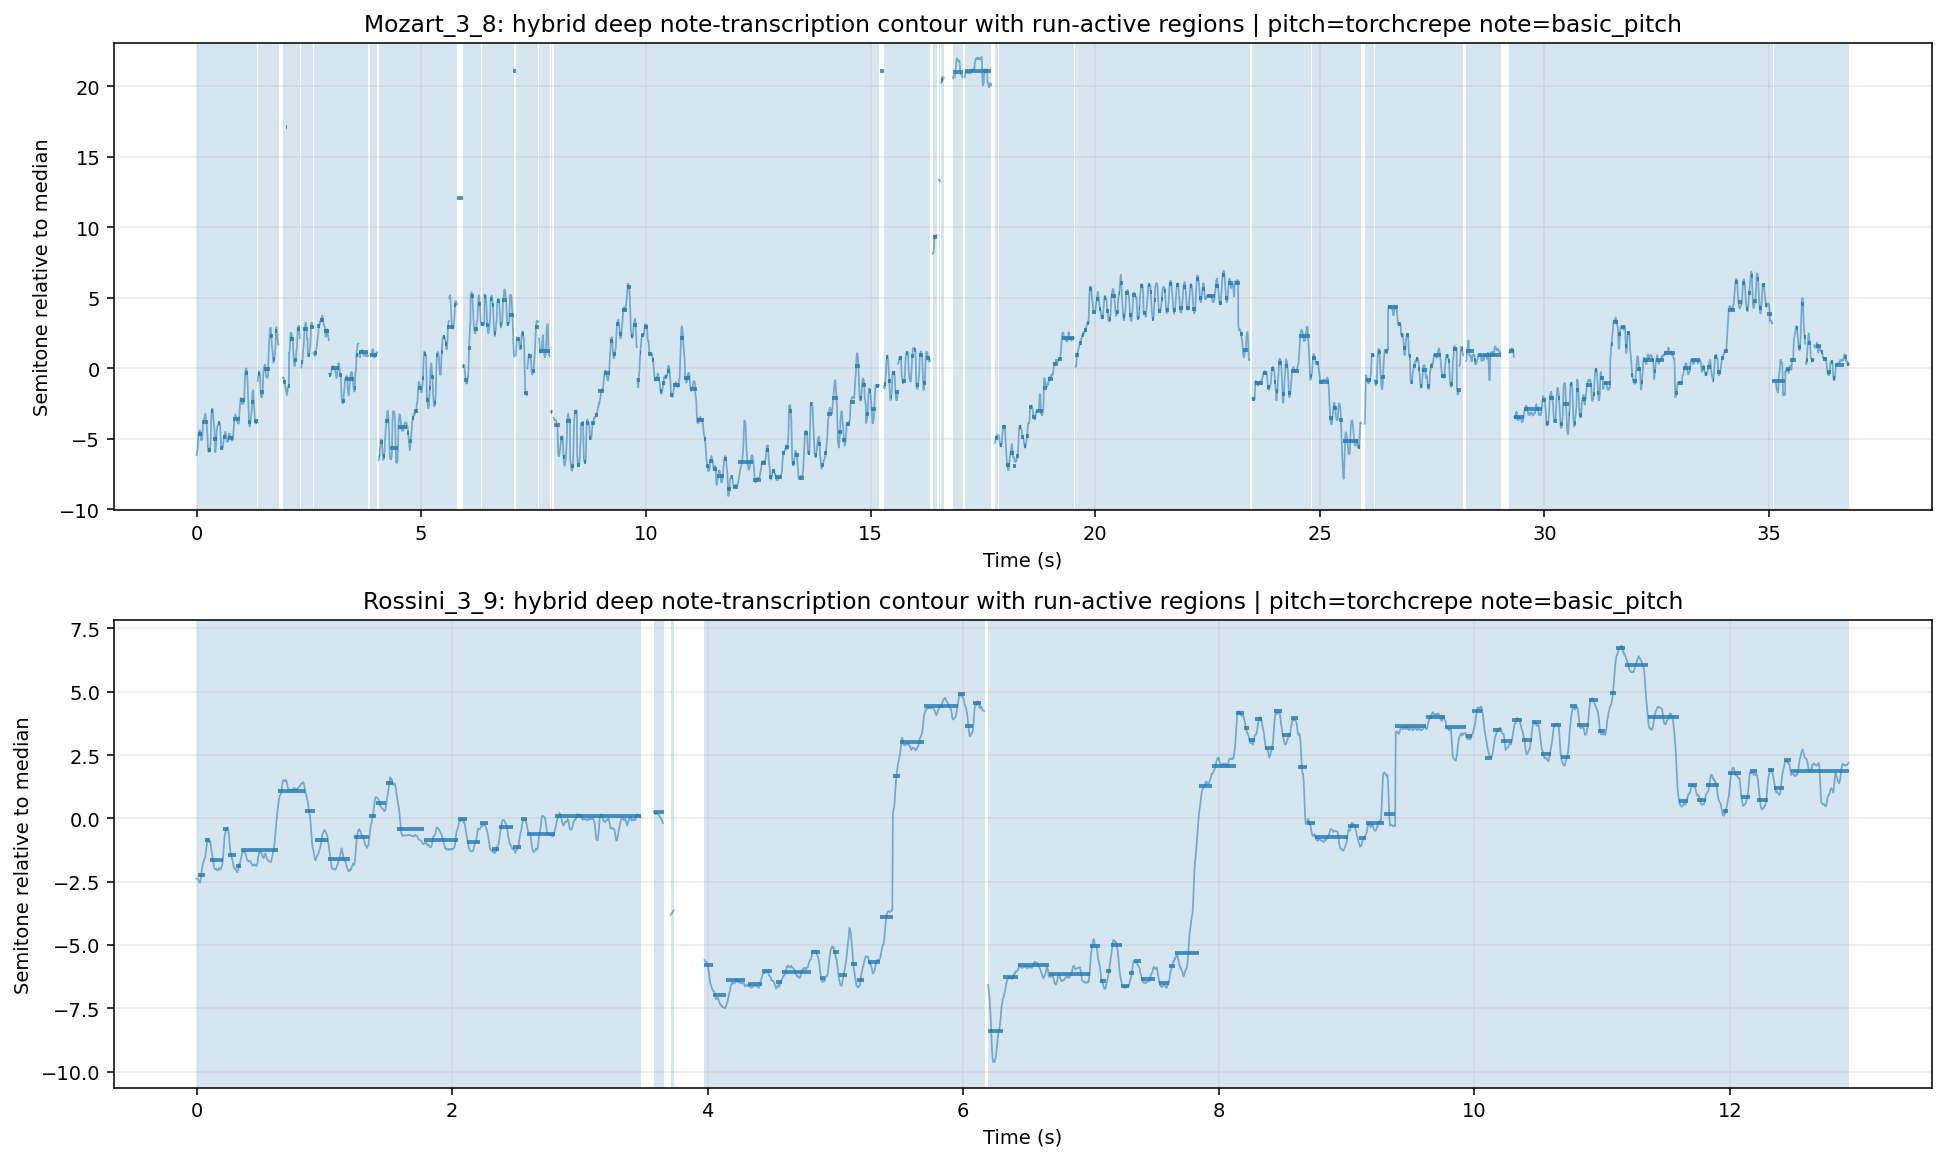

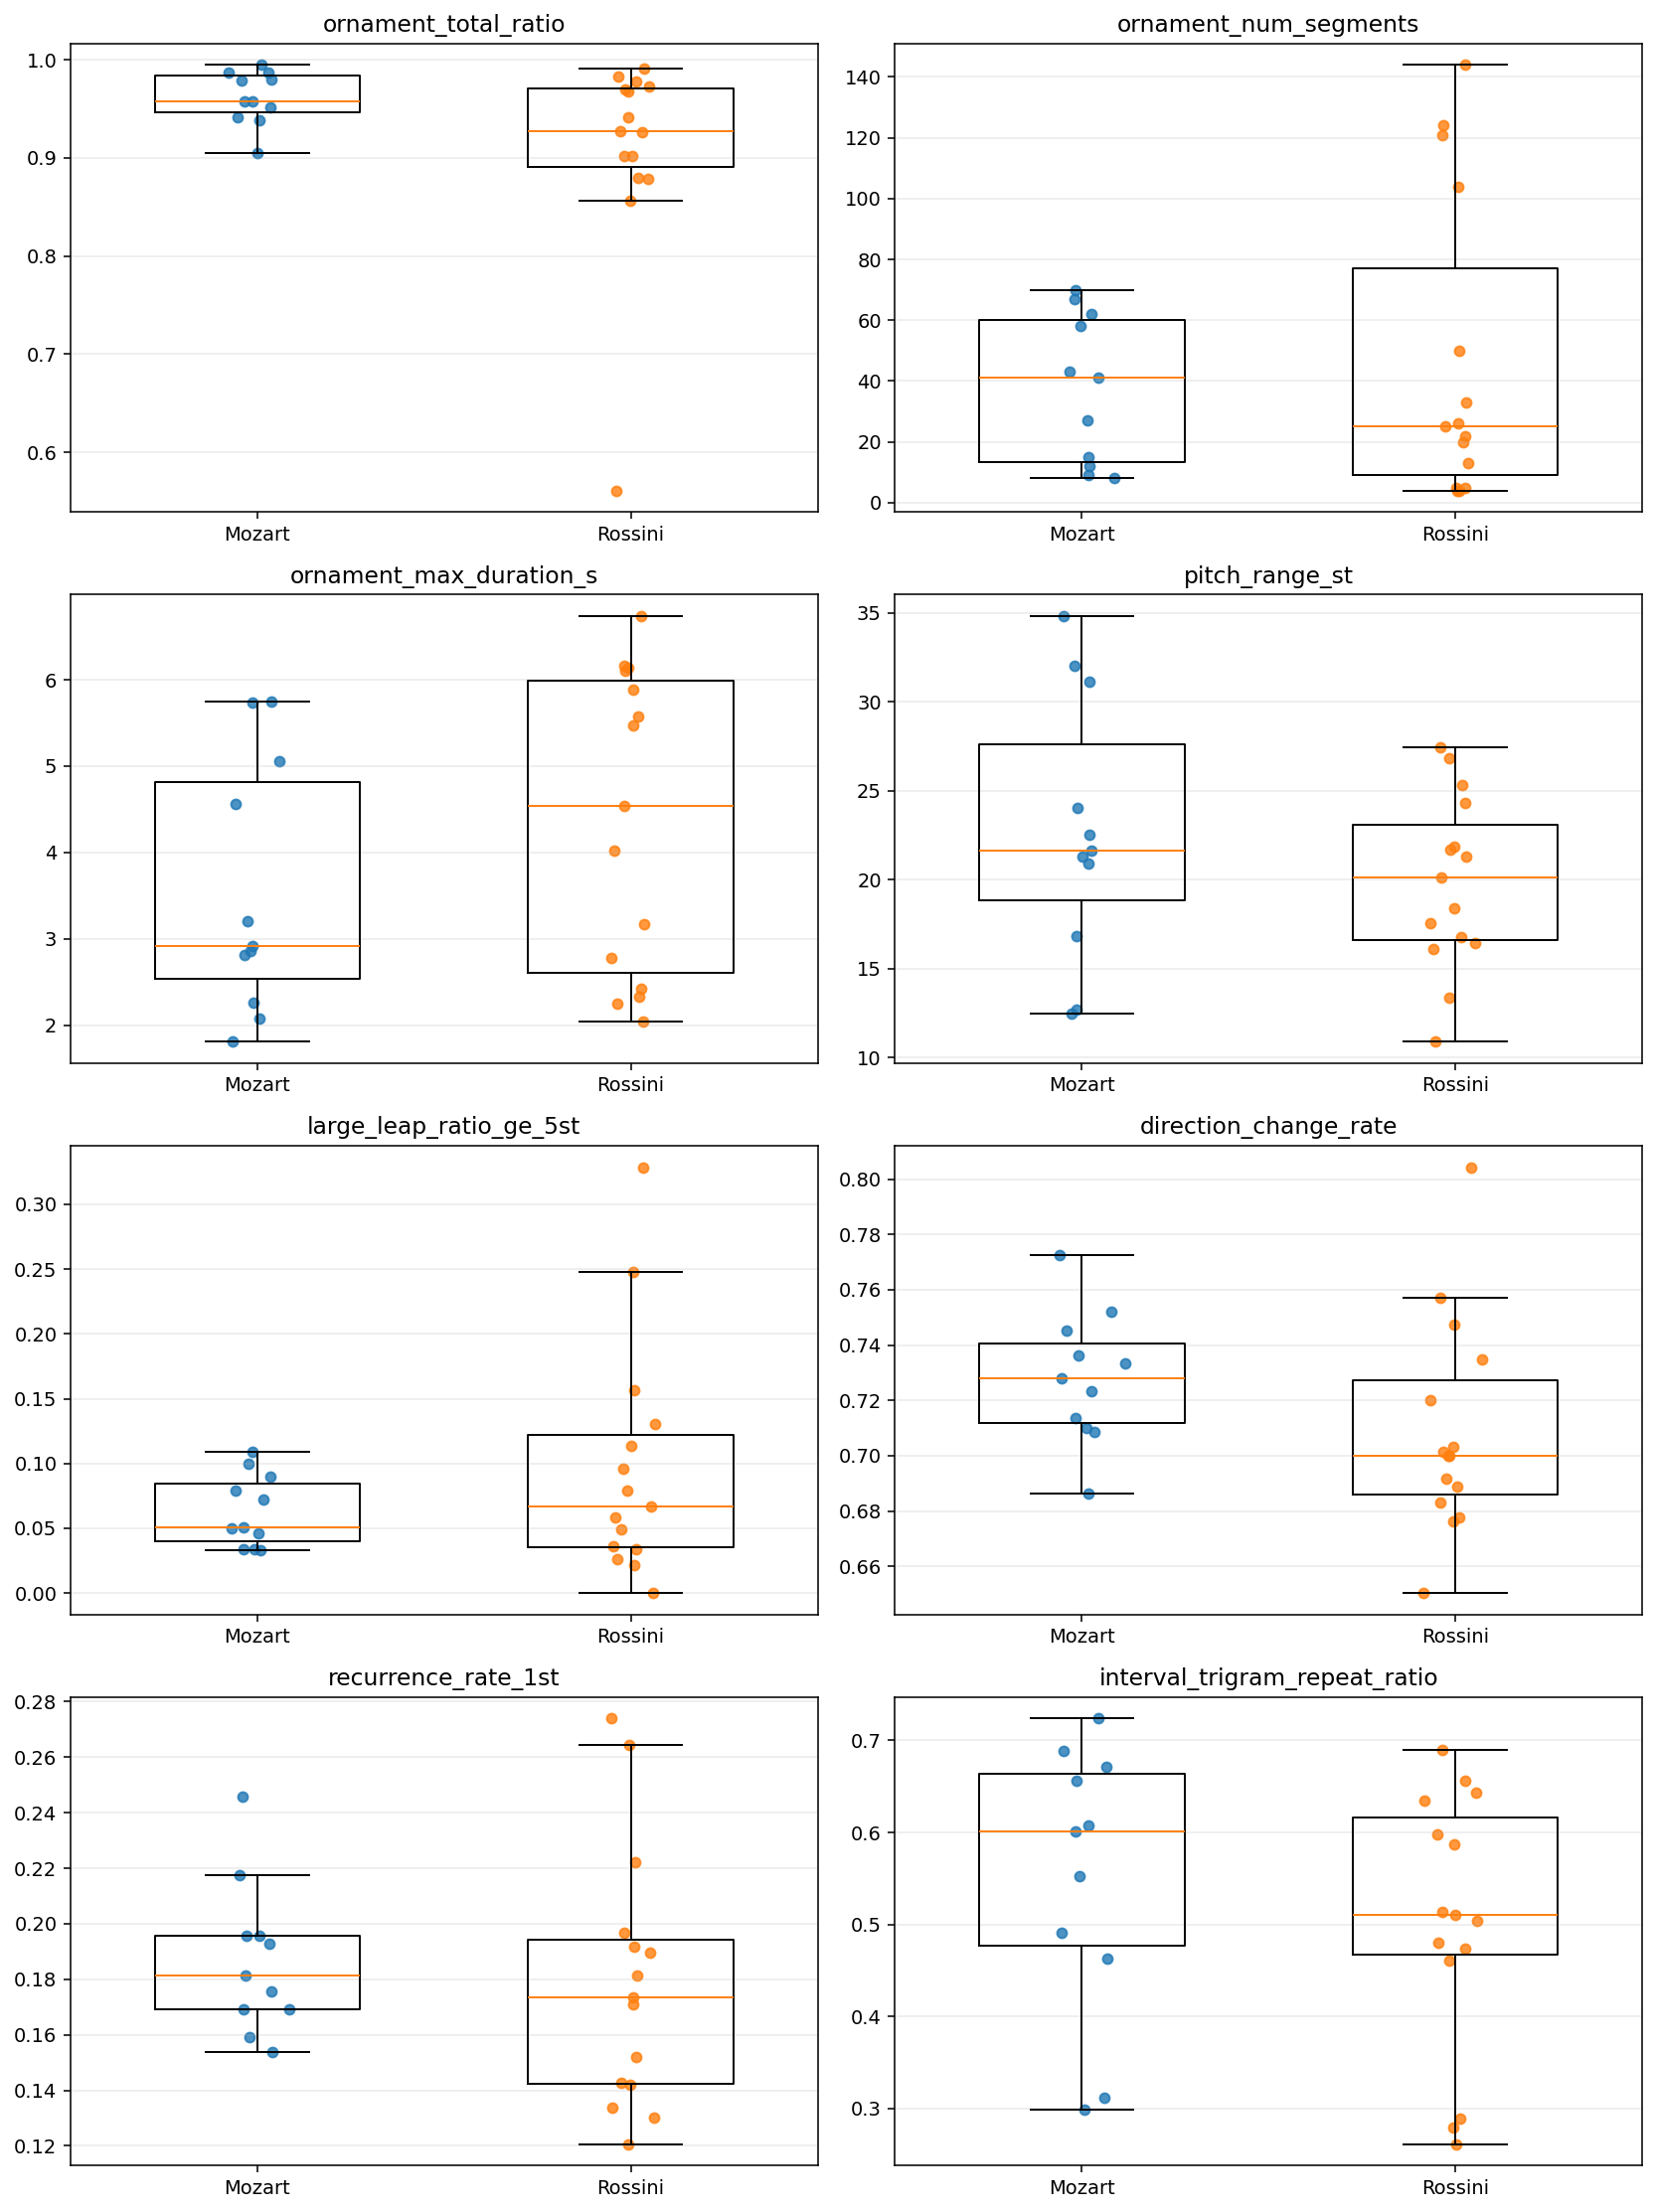


Group summary saved to: Cadenza_Analysis_Results/csv/group_summary.csv
         ornament_total_ratio                     ornament_num_segments  \
                         mean    median       std                  mean   
composer                                                                  
Mozart               0.961847  0.957983  0.027159             37.454545   
Rossini              0.909000  0.926956  0.105396             46.666667   

                           ornament_max_duration_s                   \
         median        std                    mean median       std   
composer                                                              
Mozart     41.0  24.369504                3.547273   2.91  1.461667   
Rossini    25.0  49.948068                4.376048   4.54  1.730147   

         pitch_range_st  ... large_leap_ratio_ge_5st direction_change_rate  \
                   mean  ...                     std                  mean   
composer                 ...            

Python(91994) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Silhouette score = 0.285
Adjusted Rand Index (cluster vs composer label) = 0.016
Cluster assignments saved to: Cadenza_Analysis_Results/csv/cluster_assignments.csv
            stem composer  cluster       PC1       PC2
0     Mozart_1_1   Mozart        0  1.187874  0.444409
1     Mozart_1_2   Mozart        0  0.494151  1.819972
2     Mozart_1_3   Mozart        0  0.555577  0.704409
3     Mozart_2_4   Mozart        0  1.256200 -2.721434
4     Mozart_2_5   Mozart        0  2.369238 -2.777562
5     Mozart_3_6   Mozart        0  1.092873  0.590726
6     Mozart_3_7   Mozart        1 -1.204029  1.225578
7     Mozart_3_8   Mozart        0  0.332838  1.924905
8     Mozart_3_9   Mozart        1 -0.552188 -0.111669
9    Mozart_4_10   Mozart        0 -0.024937  0.064572
10   Mozart_4_11   Mozart        0 -0.172923  1.227261
11   Rossini_1_1  Rossini        1 -2.060573  1.114481
12   Rossini_1_2  Rossini        1 -3.898693  0.843024
13   Rossini_1_3  Rossini        1 -2.744667  0.891111
14   Rossi

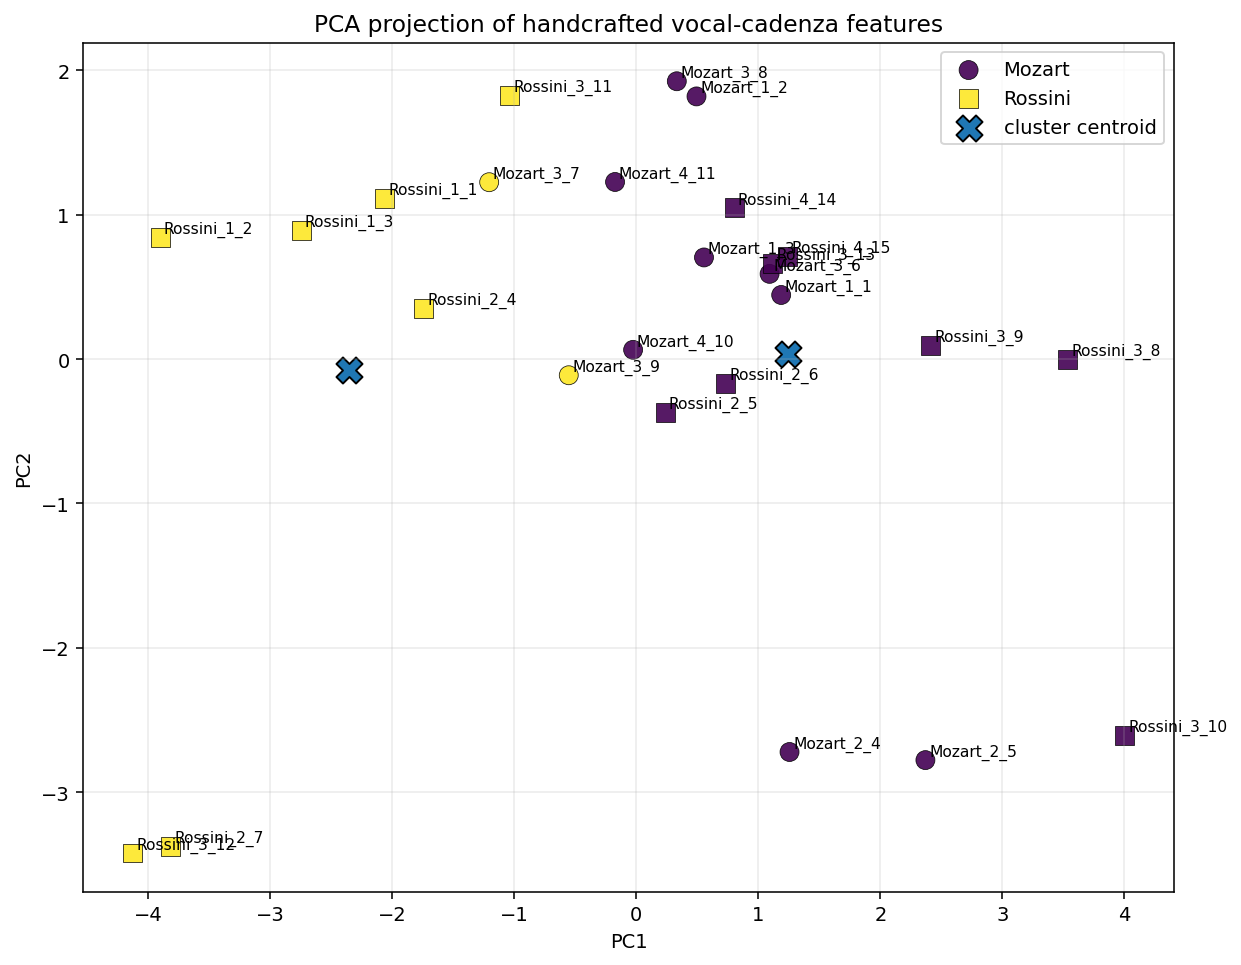

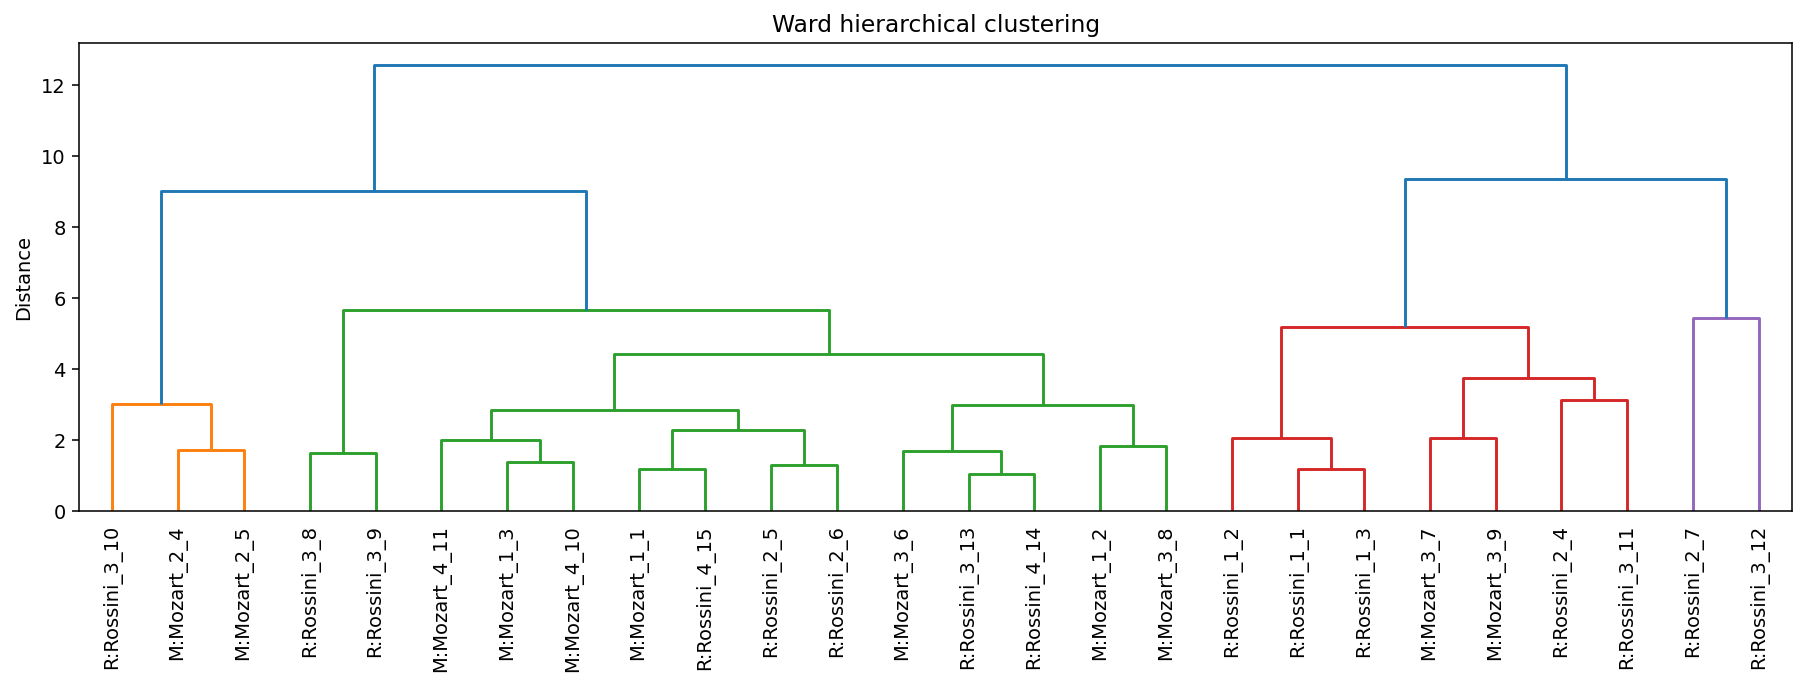


All figures are saved under: Cadenza_Analysis_Results/figures


In [3]:
metadata = list_audio_files(DATA_DIR)
print(metadata)

wav_paths = convert_inputs_to_wav(metadata, INPUT_WAV_DIR, target_sr=SR_DEMUCS)
run_demucs_two_stems(wav_paths, SEP_ROOT, VOCAL_DIR, ACC_DIR, model_name="htdemucs")

rows = []
diagnostics_map = {}

for row in tqdm(metadata.itertuples(index=False), total=len(metadata), desc="Extracting vocal features"):
    vocal_path = VOCAL_DIR / f"{row.stem}_vocals.wav"
    feats, diag = compute_features_for_file(vocal_path, composer=row.composer)
    if feats is None:
        continue
    feats["stem"] = row.stem
    feats["source_path"] = str(row.path)
    feats["vocal_path"] = str(vocal_path)
    feats["acc_path"] = str(ACC_DIR / f"{row.stem}_acc.wav")
    rows.append(feats)
    diagnostics_map[row.stem] = diag

features_df = pd.DataFrame(rows).sort_values(["composer", "stem"]).reset_index(drop=True)
features_csv = CSV_DIR / "cadenza_features.csv"
features_df.to_csv(features_csv, index=False)
print("\nFeature table saved to:", features_csv)
print(features_df.head())

plot_example_contours(features_df, diagnostics_map, FIG_DIR / "01_example_contours.png")

PLOT_FEATURES = [
    "ornament_total_ratio",
    "ornament_num_segments",
    "ornament_max_duration_s",
    "pitch_range_st",
    "large_leap_ratio_ge_5st",
    "direction_change_rate",
    "recurrence_rate_1st",
    "interval_trigram_repeat_ratio",
]
plot_group_distributions(features_df, PLOT_FEATURES, FIG_DIR / "02_group_distributions.png")

summary = features_df.groupby("composer")[PLOT_FEATURES].agg(["mean", "median", "std"])
summary_csv = CSV_DIR / "group_summary.csv"
summary.to_csv(summary_csv)
print("\nGroup summary saved to:", summary_csv)
print(summary)

CLUSTER_FEATURES = [
    "ornament_total_ratio",
    "ornament_num_segments",
    "ornament_max_duration_s",
    "pitch_range_st",
    "abs_interval_mean_st",
    "large_leap_ratio_ge_5st",
    "direction_change_rate",
    "recurrence_rate_1st",
    "interval_trigram_repeat_ratio",
    "pitch_entropy",
]

cluster_df = features_df[["stem", "composer"] + CLUSTER_FEATURES].copy()
for col in CLUSTER_FEATURES:
    cluster_df[col] = cluster_df[col].astype(float)
    cluster_df[col] = cluster_df[col].fillna(cluster_df[col].median())

X = cluster_df[CLUSTER_FEATURES].values
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(Xz)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=50)
clusters = kmeans.fit_predict(Xz)

cluster_df["cluster"] = clusters
cluster_df["PC1"] = X2[:, 0]
cluster_df["PC2"] = X2[:, 1]

sil = silhouette_score(Xz, clusters)
print(f"\nSilhouette score = {sil:.3f}")

known_mask = cluster_df["composer"].isin(["Mozart", "Rossini"])
if known_mask.any():
    true_labels = cluster_df.loc[known_mask, "composer"].map({"Mozart": 0, "Rossini": 1}).values
    pred_labels = cluster_df.loc[known_mask, "cluster"].values
    ari = adjusted_rand_score(true_labels, pred_labels)
    print(f"Adjusted Rand Index (cluster vs composer label) = {ari:.3f}")

cluster_csv = CSV_DIR / "cluster_assignments.csv"
cluster_df.to_csv(cluster_csv, index=False)
print("Cluster assignments saved to:", cluster_csv)
print(cluster_df[["stem", "composer", "cluster", "PC1", "PC2"]])

plot_cluster_scatter(cluster_df, pca, kmeans, FIG_DIR / "03_cluster_scatter_pca.png")
plot_dendrogram(cluster_df, Xz, FIG_DIR / "04_cluster_dendrogram.png")

print("\nAll figures are saved under:", FIG_DIR)


Loaded: Cadenza_Analysis_Results/csv/cadenza_features.csv
Loaded: Cadenza_Analysis_Results/csv/cluster_assignments.csv
features_df shape: (26, 29)
cluster_df shape: (26, 15)
Saved: Cadenza_Analysis_Results/figures_visual_only/02_group_distributions_red_blue_transparent.png


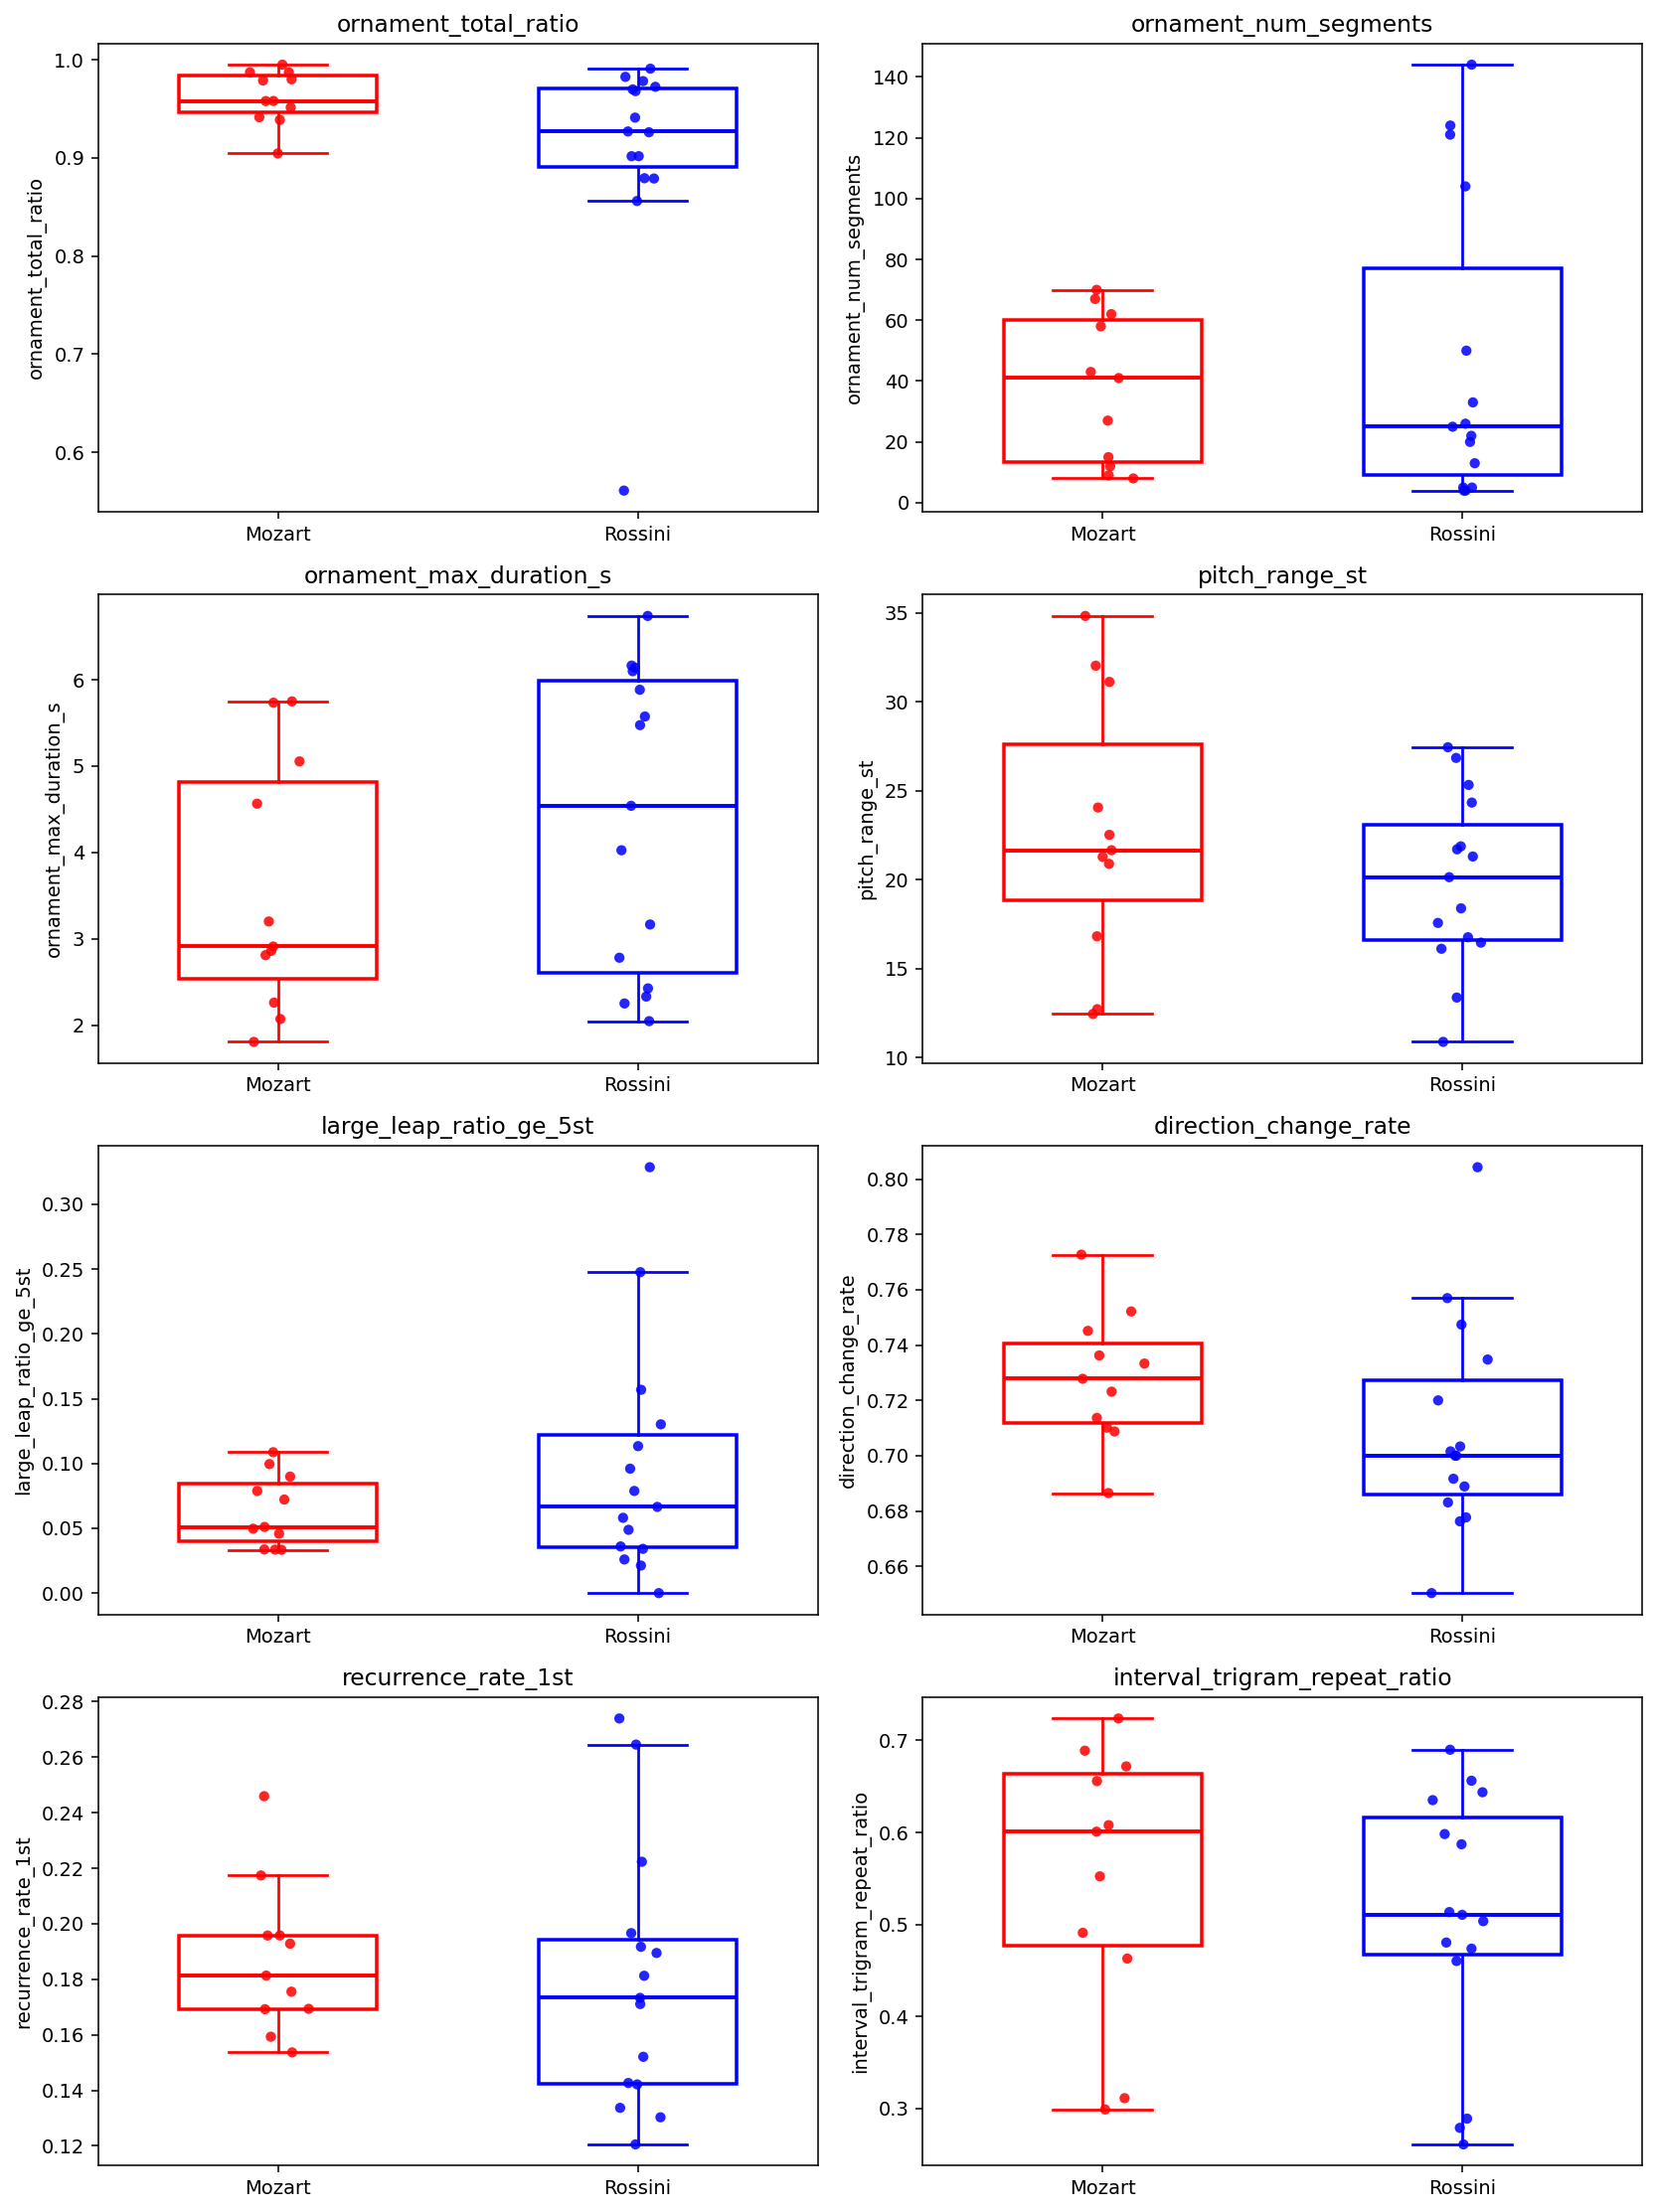

Saved: Cadenza_Analysis_Results/figures_visual_only/03_cluster_scatter_pca_red_blue_transparent.png


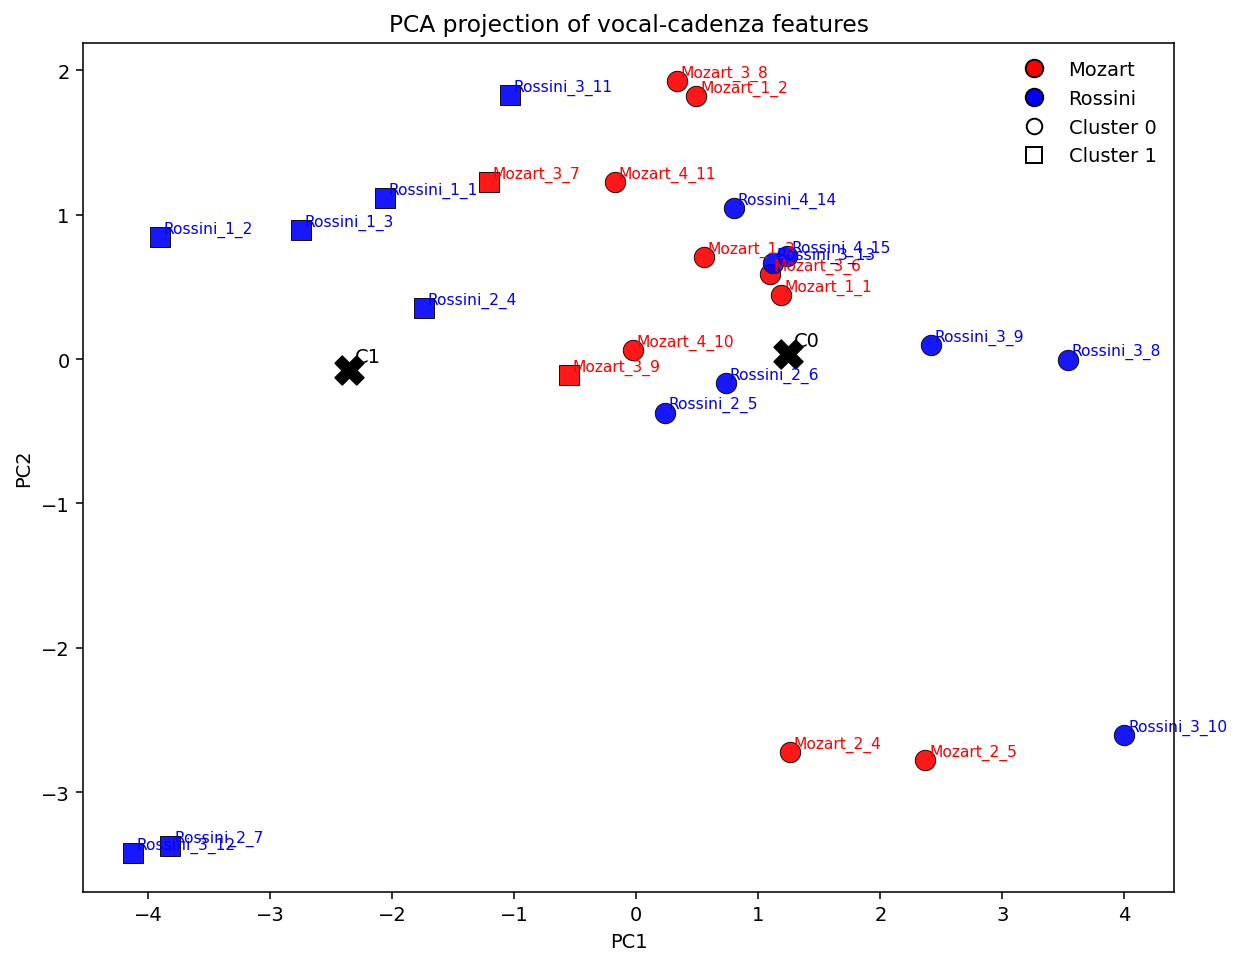

Saved: Cadenza_Analysis_Results/figures_visual_only/04_cluster_dendrogram_red_blue_transparent.png


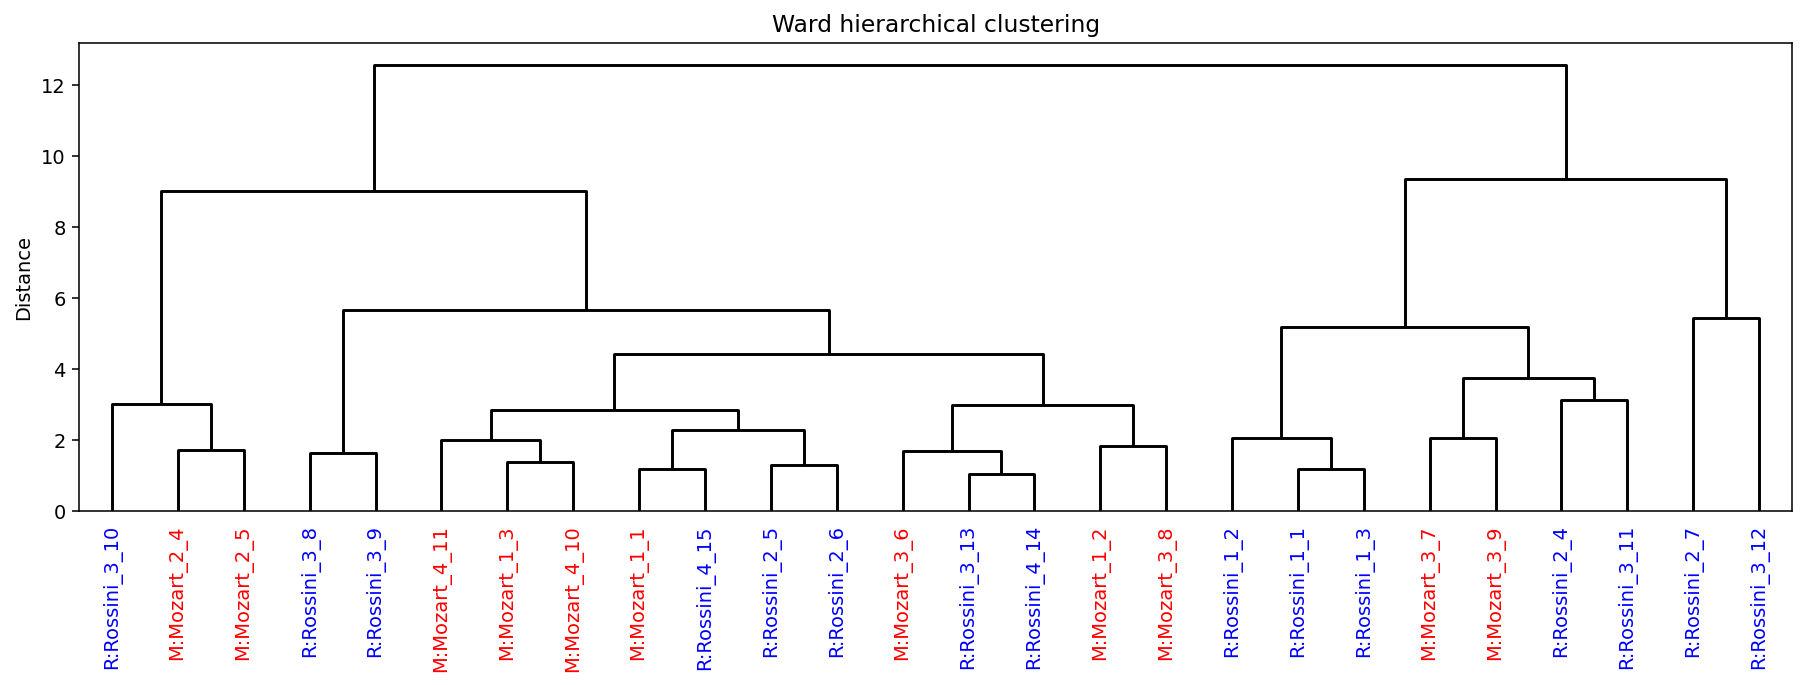

In [4]:
# =========================
# Visualisation only
# 直接读取已保存 CSV，重新绘图
# Mozart = red, Rossini = blue
# 透明背景，关闭 grid
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler

# -------------------------
# 路径
# -------------------------
ROOT = Path("Cadenza_Analysis_Results")
CSV_DIR = ROOT / "csv"
OUT_DIR = ROOT / "figures_visual_only"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_CSV = CSV_DIR / "cadenza_features.csv"
CLUSTER_CSV = CSV_DIR / "cluster_assignments.csv"

if not FEATURES_CSV.exists():
    raise FileNotFoundError(f"找不到特征文件: {FEATURES_CSV}")

if not CLUSTER_CSV.exists():
    raise FileNotFoundError(f"找不到聚类文件: {CLUSTER_CSV}")

features_df = pd.read_csv(FEATURES_CSV)
cluster_df = pd.read_csv(CLUSTER_CSV)

print("Loaded:", FEATURES_CSV)
print("Loaded:", CLUSTER_CSV)
print("features_df shape:", features_df.shape)
print("cluster_df shape:", cluster_df.shape)

# -------------------------
# 全局绘图风格
# -------------------------
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.grid"] = False
plt.rcParams["figure.facecolor"] = "none"
plt.rcParams["axes.facecolor"] = "none"
plt.rcParams["savefig.facecolor"] = "none"
plt.rcParams["savefig.edgecolor"] = "none"

COLOR_MAP = {
    "Mozart": "red",
    "Rossini": "blue",
    "Unknown": "gray",
}

# 这些特征与你前面的主脚本保持一致
PLOT_FEATURES = [
    "ornament_total_ratio",
    "ornament_num_segments",
    "ornament_max_duration_s",
    "pitch_range_st",
    "large_leap_ratio_ge_5st",
    "direction_change_rate",
    "recurrence_rate_1st",
    "interval_trigram_repeat_ratio",
]

CLUSTER_FEATURES = [
    "ornament_total_ratio",
    "ornament_num_segments",
    "ornament_max_duration_s",
    "pitch_range_st",
    "abs_interval_mean_st",
    "large_leap_ratio_ge_5st",
    "direction_change_rate",
    "recurrence_rate_1st",
    "interval_trigram_repeat_ratio",
    "pitch_entropy",
]

GROUPS = ["Mozart", "Rossini"]


def make_ax_transparent(ax):
    ax.set_facecolor("none")
    ax.grid(False)
    return ax


def finish_figure(fig, out_path=None):
    fig.patch.set_alpha(0.0)
    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=300, bbox_inches="tight", transparent=True)
        print("Saved:", out_path)
    plt.show()


def plot_group_distributions_from_csv(df, features, out_path=None):
    cols = 2
    rows = int(np.ceil(len(features) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
    axes = axes.flatten()
    rng = np.random.default_rng(42)

    for ax, feat in zip(axes, features):
        make_ax_transparent(ax)

        data = [df.loc[df["composer"] == g, feat].dropna().values for g in GROUPS]

        # boxplot：边框按组着色，内部透明
        bp = ax.boxplot(
            data,
            labels=GROUPS,
            widths=0.55,
            showfliers=False,
            patch_artist=True
        )

        for i, g in enumerate(GROUPS):
            c = COLOR_MAP[g]

            # box
            bp["boxes"][i].set_facecolor("none")
            bp["boxes"][i].set_edgecolor(c)
            bp["boxes"][i].set_linewidth(1.8)

            # median
            bp["medians"][i].set_color(c)
            bp["medians"][i].set_linewidth(2.0)

            # whiskers / caps
            bp["whiskers"][2 * i].set_color(c)
            bp["whiskers"][2 * i + 1].set_color(c)
            bp["caps"][2 * i].set_color(c)
            bp["caps"][2 * i + 1].set_color(c)

            bp["whiskers"][2 * i].set_linewidth(1.4)
            bp["whiskers"][2 * i + 1].set_linewidth(1.4)
            bp["caps"][2 * i].set_linewidth(1.4)
            bp["caps"][2 * i + 1].set_linewidth(1.4)

        # 数据点：Mozart 红，Rossini 蓝
        for i, (g, vals) in enumerate(zip(GROUPS, data), start=1):
            if len(vals) == 0:
                continue
            jitter = rng.normal(0.0, 0.04, size=len(vals))
            ax.scatter(
                np.full(len(vals), i) + jitter,
                vals,
                s=28,
                color=COLOR_MAP[g],
                alpha=0.85,
                edgecolors="none"
            )

        ax.set_title(feat)
        ax.set_xlabel("")
        ax.set_ylabel(feat)

    for ax in axes[len(features):]:
        ax.axis("off")

    finish_figure(fig, out_path)


def plot_cluster_scatter_from_csv(cluster_df, out_path=None):
    df = cluster_df.copy()

    # cluster 字段可能读成 float，这里强制转 int
    if "cluster" in df.columns:
        df["cluster"] = df["cluster"].astype(int)

    fig, ax = plt.subplots(figsize=(9, 7))
    make_ax_transparent(ax)

    # 用形状区分 cluster，用颜色区分 composer
    cluster_marker_map = {0: "o", 1: "s"}

    for _, row in df.iterrows():
        composer = row["composer"]
        colour = COLOR_MAP.get(composer, "gray")
        marker = cluster_marker_map.get(int(row["cluster"]), "o")

        ax.scatter(
            row["PC1"],
            row["PC2"],
            s=110,
            color=colour,
            marker=marker,
            alpha=0.9,
            edgecolors="black",
            linewidths=0.5
        )
        ax.text(
            row["PC1"] + 0.03,
            row["PC2"] + 0.03,
            row["stem"],
            fontsize=8,
            color=colour
        )

    # 用 cluster 内部在 PCA 平面上的均值近似标出中心
    if "cluster" in df.columns:
        centers = df.groupby("cluster")[["PC1", "PC2"]].mean()
        for cid, center in centers.iterrows():
            ax.scatter(
                center["PC1"],
                center["PC2"],
                marker="X",
                s=220,
                color="black",
                edgecolors="black",
                linewidths=0.8
            )
            ax.text(
                center["PC1"] + 0.05,
                center["PC2"] + 0.05,
                f"C{cid}",
                fontsize=10,
                color="black"
            )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("PCA projection of vocal-cadenza features")

    composer_handles = [
        Line2D([0], [0], marker="o", color="none", label="Mozart",
               markerfacecolor="red", markeredgecolor="black", markersize=9),
        Line2D([0], [0], marker="o", color="none", label="Rossini",
               markerfacecolor="blue", markeredgecolor="black", markersize=9),
    ]

    cluster_handles = [
        Line2D([0], [0], marker="o", color="black", label="Cluster 0",
               markerfacecolor="white", markeredgecolor="black", markersize=8, linestyle="None"),
        Line2D([0], [0], marker="s", color="black", label="Cluster 1",
               markerfacecolor="white", markeredgecolor="black", markersize=8, linestyle="None"),
    ]

    ax.legend(handles=composer_handles + cluster_handles, frameon=False, loc="best")

    finish_figure(fig, out_path)


def plot_dendrogram_from_csv(features_df, out_path=None):
    # 从保存的特征文件重新标准化并画树状图
    df = features_df[["stem", "composer"] + CLUSTER_FEATURES].copy()

    for col in CLUSTER_FEATURES:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(df[col].median())

    X = df[CLUSTER_FEATURES].values
    Xz = StandardScaler().fit_transform(X)
    Z = linkage(Xz, method="ward")

    labels = []
    for composer, stem in zip(df["composer"], df["stem"]):
        if composer == "Mozart":
            labels.append(f"M:{stem}")
        elif composer == "Rossini":
            labels.append(f"R:{stem}")
        else:
            labels.append(f"U:{stem}")

    fig, ax = plt.subplots(figsize=(13, 5))
    make_ax_transparent(ax)

    dendrogram(
        Z,
        labels=labels,
        leaf_rotation=90,
        ax=ax,
        color_threshold=0,
        above_threshold_color="black"
    )

    # 标签按 composer 上色
    for tick in ax.get_xmajorticklabels():
        txt = tick.get_text()
        if txt.startswith("M:"):
            tick.set_color("red")
        elif txt.startswith("R:"):
            tick.set_color("blue")
        else:
            tick.set_color("gray")

    ax.set_title("Ward hierarchical clustering")
    ax.set_ylabel("Distance")

    finish_figure(fig, out_path)


# -------------------------
# 运行：只可视化，不重跑前处理
# -------------------------
plot_group_distributions_from_csv(
    features_df,
    PLOT_FEATURES,
    OUT_DIR / "02_group_distributions_red_blue_transparent.png"
)

plot_cluster_scatter_from_csv(
    cluster_df,
    OUT_DIR / "03_cluster_scatter_pca_red_blue_transparent.png"
)

plot_dendrogram_from_csv(
    features_df,
    OUT_DIR / "04_cluster_dendrogram_red_blue_transparent.png"
)